# From a business risk to a compute hedge — Part 2

**The decision:** what could go wrong in this person's business, and what protection would help?

We follow twelve situations, starting with the person and the money they need to protect. For each one, we explain the inputs, work through the calculation, and show what happens when prices or paid hours change.

An **input** is a number or assumption we supply. An **output** is a result calculated from those inputs. The examples have saved outputs, so you can read without running Python. If you edit an input, run its calculation again; the written explanations describe the original numbers.

Start with cases 1–3, or choose a situation from the table below. Case 9 takes more time because it follows both sides of a customer contract. No finance background is required; [Part 1](case_hedge_converter.ipynb) provides another introduction to puts and calls.

The people are fictional. **Supplied inputs** come from the ideas used to build this notebook. **Added teaching assumptions** fill in missing details so we can calculate an example. Links to real deals explain the connection, but our example numbers are not those deals' terms. The calculations show what a proposed contract would pay, not what someone would charge to sell it.

| Case | Person's decision | Protection explored |
|---|---|---|
| 1 | How much resale income can I stabilize? | Partial forward / swap |
| 2 | Can I cover each quarter's cash requirement? | Quarterly put strip |
| 3 | What upside will I exchange for cheaper protection? | Collar |
| 4 | Can I wait to learn whether a customer renews? | Swaption |
| 5 | Can I stabilize the difference between two rental rates? | Tenor spread swap |
| 6 | Can I protect the margin after electricity costs? | Compute and power swaps |
| 7 | What price floor supports my debt-service target? | Financing-linked put |
| 8 | Who pays for hours if customers do not appear? | Quantity backstop plus put |
| 9 | Can buyer and operator share future price changes? | Indexed offtake with floor and cap |
| 10 | Can I keep some resale upside while buying a floor? | Tenor-trade collar |
| 11 | Can I insure a minimum spread without fixing the upside? | Tenor spread put |
| 12 | Can I spread my hedge decisions over time? | Layered hedge program |

[Curriculum roadmap](README.md)

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

## Before the cases: connect each term to a payment

A **GPU** is a processor used for computing work. **Capacity** means computing service available to use or rent. One **GPU-hour** means one GPU available for one hour: 10 GPUs for three hours is 30 GPU-hours.

**Available hours** include both sold and idle capacity. **Billed hours** are hours charged to customers. **Billed utilization** is the share of available hours that customers pay for. A customer may pay for reserved hours without using them. We use **730 hours per GPU per month** as a simplifying assumption; real calendar months vary.

**USD** means US dollars. In the tables, **USD/h** means USD per GPU-hour, and **m** after a number means million. **Revenue** is income from customers before costs. **Receipts** are money collected. **Margin** is the amount left after the costs named in that example; it is not necessarily profit after every business expense.

A **hedge** is a contract intended to offset a particular business risk. A financial hedge pays money; the **physical contract** arranges the actual computing service. An **exposure** is the amount of business affected by a change in price or quantity.

An **index** is the reference price named in the contract. **Basis** is the difference between an actual business price and that index. A **fixed** rate stays unchanged under the contract; a **floating** rate changes with the reference price.

A **forward** can fix the financial result for one future period. A **swap** can repeat that calculation over several periods. For a seller who agrees to **receive fixed and pay the index**, subtract the index from the agreed fixed rate, then multiply by covered hours. Usually only the difference is paid. If the fixed rate is USD 2 and the index is USD 1.50, the seller receives USD 0.50 per covered hour. If the index is USD 2.50, the seller pays USD 0.50 instead.

A purchased **put** pays when the index is below its **strike**, the price threshold written into the option. A purchased **call** pays when the index is above its strike. The **premium** is the price paid to buy the option, even if it later pays nothing. The payment before subtracting that premium is the **payoff**. The **counterparty** is the other person or business that owes or receives the contract's payments.

The option's **notional** is the quantity used to multiply its payment per hour. A USD 0.50 payout on 100,000 GPU-hours means USD 50,000. Notional is neither the premium nor a delivery of physical GPUs. In code, `max(difference, 0)` means “pay the positive difference; otherwise pay zero.”

A **floor** is a minimum rate or receipt; a **cap** is a maximum. We will distinguish the contract's floor or cap from the result after paying for protection. **Gross** means before a stated deduction; **net** means after it. Positive hedge receipts in the tables mean money coming in; negative receipts mean money paid out.

**When money moves:** settlement means making the payment required by a contract. Unless stated otherwise, customer payments and hedge payments arrive together at each period's end. **Month 0** is the starting date; month 6 is six months later. These are teaching assumptions, not standard payment terms. An invoice date is the date a bill is issued; cash may arrive later in a real deal.

**Premium timing in these teaching examples:** assume purchased-option premiums are paid at the start and sold-option premiums are received then. Where no premium is supplied, the results exclude that unknown cost; exclusion does not mean the option is free. The swaps shown have no modeled upfront payment. Real quotes must specify any upfront amount, fees and collateral.

The examples leave out taxes, transaction fees and **collateral**, cash or assets pledged to support a contract. They add dollars without **discounting**, which adjusts future cash to a value today. A matching final total therefore does not show whether the business has enough cash for earlier bills.

At the end of each case, “what to ask a dealer to quote” describes a proposed contract. A **dealer** is a business offering to trade it. A quote supplies its proposed price and terms; the business's desired rate alone does not establish what the dealer will offer.

In [2]:
from IPython.display import display
from matplotlib.ticker import StrMethodFormatter

from liquid_compute.education import plot_finance_series, show_finance_table
from liquid_compute.financing import debt_service_coverage
from liquid_compute.hedge_converter import (
    financing_hedge_requirement,
    revenue_floor_hedge_terms,
)
from liquid_compute.hedging import (
    forward_settlements_usd,
    spread_swap_settlement_usd,
)
from liquid_compute.options import (
    european_option_payoff_usd,
    tenor_spread_put_payoff_usd,
)
from liquid_compute.power import power_swap_receipt_usd

## 1. Alex, the capacity reseller: protect part of the resale income

**Product:** Partial forward / swap

**What Alex is worried about:** “I promised to pay USD 4.25 per hour for three years. My customers only commit for short periods. If the next customers pay less, my purchase bill stays the same. If I cannot find customers, I still owe that bill.”

**What he wants to protect:** A USD 4.85 selling rate on one-third of the hours available in year 1. He accepts that the other two-thirds will earn whatever customers pay at the time.

**How the hedge helps:** The swap pays Alex when the index is below 4.85. Alex pays the swap counterparty when it is above 4.85. If his customers pay the index rate, those two cash flows leave him with 4.85 on the covered hours. He still needs customers to buy them.

**The payment steps — Alex receives fixed and pays floating.**

1. **Agree the swap.** Alex and the swap counterparty fix the rate at **USD 4.85** on **186,880 GPU-hours over months 1–12**, split equally by month. The swap quantity is agreed in advance; it does not automatically shrink if Alex sells fewer hours. This example includes no upfront swap payment.
2. **Keep selling compute.** Customers pay Alex the changing B300 short-rental index. Alex separately owes his capacity supplier **USD 4.25 on every available hour**, including idle hours.
3. **Settle the swap each month.** On the covered hours, the counterparty owes Alex the fixed rate and Alex owes the counterparty the index rate. They subtract one amount from the other and pay only the difference: `monthly covered hours × (4.85 − monthly index)`.
4. **Combine the money.** At an index of **4.20**, the counterparty pays Alex **0.65 per covered hour**; customer receipts plus the swap equal 4.85. At **5.30**, Alex pays the counterparty **0.45 per covered hour**; 5.30 minus 0.45 again leaves 4.85. At exactly 4.85, no swap payment is due. The supplier bill is still payable separately.

The swap is a cash contract. The swap counterparty does not buy Alex's computing hours or find customers for them. This case uses monthly swap payments; a single-period forward would apply the same subtraction once for its specified period.

Alex is a **capacity reseller**: he buys access to compute and resells that access without owning the GPUs. **Tenor** means contract length. His **tenor trade** is a long rental purchase followed by repeated shorter rentals to customers.

Alex's supplied inputs:

| Input in code | Value and units | Meaning |
|---|---|---|
| `gpu_count` | 64 B300 GPUs | Capacity contracted for resale |
| `purchase_rate` | USD 4.25/GPU-hour | Fixed cost for every available hour, for 3 years |
| `months`, `hours_per_month` | 12 months; 730 hours/GPU/month | Only year 1 is hedged here |
| `hedge_fraction` | 1/3 | Share of available first-year hours hedged |
| `fixed_rate` | USD 4.85/GPU-hour | Target fixed hedge rate, not a verified quote |
| `index` scenarios | USD 4.20 and 5.30/GPU-hour | Low-price outcome and supplied starting short rental rate |

**Added teaching assumptions:** Alex's selling price equals the hedge index. Each row assumes that price stays constant throughout the year. The first two rows sell every available hour; the third sells only 70%. Customer and swap payments occur monthly, and the table adds them for year 1. We calculate the year's capacity purchase cost, without modeling the three-year prepayment and financing schedule.

**How we find the hedge quantity.** Each of 64 GPUs provides 730 hours a month for 12 months: `64 × 730 × 12 = 560,640` available hours. Alex chooses to hedge one-third: `560,640 ÷ 3 = 186,880 GPU-hours`.

**How we find the payment.** At a 4.20 index, each covered hour pays Alex `4.85 − 4.20 = USD 0.65`. At a 5.30 index, the difference is `4.85 − 5.30 = −USD 0.45`: Alex must pay. Multiply either difference by 186,880, not by all 560,640 hours.

**Source connection:** [Liquid Compute, The Tenor Trade, September 2026](https://liquidcompute.com/research/the-tenor-trade) supplies the 64-GPU, three-year example and illustrates a one-third hedge at 4.85. We retain the submitted numbers; this attribution does not verify a current executable price.

In [3]:
gpu_count = 64
purchase_rate = 4.25
months, hours_per_month = 12, 730
hedge_fraction, fixed_rate = 1 / 3, 4.85
available_hours = gpu_count * hours_per_month * months
hedge_hours = available_hours * hedge_fraction
purchase_cost = available_hours * purchase_rate
rows = []
for index, billed_utilization in [(4.20, 1.0), (5.30, 1.0), (4.20, 0.70)]:
    physical_receipts = available_hours * billed_utilization * index
    # Each month has one-twelfth of the annual hedge quantity.
    settlements = forward_settlements_usd(
        benchmark_usd_per_gpu_hour=[index] * months,
        strike_usd_per_gpu_hour=fixed_rate,
        hedge_gpu_hours=[hedge_hours / months] * months,
        settlement_months=list(range(1, months + 1)),
        side="seller",
    )
    hedge_receipt = sum(row.amount_usd for row in settlements)
    rows.append(
        [
            index,
            f"{billed_utilization:.0%}",
            hedge_receipt,
            physical_receipts - purchase_cost,
            physical_receipts + hedge_receipt - purchase_cost,
        ]
    )
print(
    f"Available: {available_hours:,.0f} GPU-hours; hedge: {hedge_hours:,.0f} GPU-hours"
)
show_finance_table(
    [
        "Index USD/h",
        "Billed fill",
        "Swap USD",
        "Unhedged margin USD",
        "Hedged margin USD",
    ],
    rows,
)

Available: 560,640 GPU-hours; hedge: 186,880 GPU-hours


| Index USD/h | Billed fill | Swap USD | Unhedged margin USD | Hedged margin USD |
| --- | --- | --- | --- | --- |
| 4.20 | 100% | 121,472.00 | -28,032.00 | 93,440.00 |
| 5.30 | 100% | -84,096.00 | 588,672.00 | 504,576.00 |
| 4.20 | 70% | 121,472.00 | -734,438.40 | -612,966.40 |

At a **USD 4.20** index with every hour sold, Alex loses USD 28,032 before the hedge. The swap adds `USD 0.65 × 186,880 = USD 121,472`. After paying for the capacity, he has **USD 93,440 left**.

At **USD 5.30**, customers pay more, but Alex owes `USD 0.45 × 186,880 = USD 84,096` on the swap. The amount left after the capacity purchase falls from USD 588,672 without a hedge to **USD 504,576 with it**. He exchanges some high-price receipts for help at lower prices.

The third row sells only 70% of available hours at USD 4.20. The purchase bill and swap quantity stay unchanged. Despite the swap receipt, Alex loses **USD 612,966.40**. This is the difference between protecting a selling rate and finding enough customers. Years 2 and 3 are also unhedged.

The table's **margin** is what remains after the capacity purchase and swap payments. Alex would still have to pay any other business expenses and financing costs.

**What Alex would ask a dealer to quote:** a swap on 15,573.333… GPU-hours each month for months 1–12. The target fixed rate is 4.85, against a precisely named B300 short-rental index. Below 4.85 Alex receives the difference; above it he pays the difference. A dealer must confirm what rate and terms it will actually offer.

## 2. Priya, the operator: cover the cash needed each quarter

**Product:** Quarterly put strip

**What Priya is worried about:** “My GPUs could keep earning rental income, but falling prices might leave me short when operating bills and loan payments are due. A good fourth quarter will not pay a bill that came due in the first quarter.”

**What she wants to protect:** USD 2 million of receipts in quarter 1, then USD 1.8 million, USD 1.5 million and USD 1.2 million in the following quarters. Those amounts cover her assumed operating costs and loan payments.

**How the hedge helps:** Priya buys a separate put for each quarter. If that quarter's index is too low to produce the required receipts from her planned hours, its put pays the price-related shortfall. A **put strip** is a set of puts covering successive periods.

**The payment steps — Priya buys four separate puts.**

1. **Buy the protection.** Priya pays the option seller premiums for four puts, each covering **1.2 million GPU-hours**. Each quarter has its own strike: **1.666666…**, **1.50**, **1.25** and **1.00 USD per hour**. We derive these thresholds below. The premiums still need quotes.
2. **Collect rental income.** Customers pay Priya for the quarter's billed hours at its average index price. Their invoices do not acquire a floor just because Priya bought puts.
3. **Calculate each quarter separately.** At months **3, 6, 9 and 12**, compare that quarter's average index with that quarter's strike. If the index is lower, the option seller pays Priya `1.2 million × (strike − average index)`. If it is equal or higher, that put pays **zero**. Priya never pays the seller a high-price difference on a put she bought.
4. **Add the put receipt to customer receipts.** In Q1 at index **1.00**, customers pay **USD 1.2 million** and the put seller pays **USD 800,000**, giving the required **USD 2 million before premium**. Q3's index of 1.40 exceeds its 1.25 strike, so that put pays zero. A high Q3 price does not cancel a Q1 payout.

The premiums purchase the protection; they are spent even if all four puts pay zero. The puts respond to the price index, not to whether Priya actually collected enough customer cash.

A **quarter** is three months. **Debt service** means the loan principal and interest due: principal is borrowed money being repaid, and interest is the charge for borrowing it. The cash requirements below already include operating costs and debt service, so we must not add them again.

Priya's supplied inputs:

| Input | Supplied value | Meaning |
|---|---|---|
| `required_cash` | USD 2m, 1.8m, 1.5m, 1.2m | Gross receipts needed in quarters 1–4 |
| `quarter_hours` | 1,200,000 GPU-hours each quarter | Expected paid hours generating those receipts |

**Added teaching assumptions:** Priya bills 1.2 million GPU-hours in each quarter, at that quarter's average index rate. She sells equal quantities at each price observation, so the index average also describes her average selling rate. The four puts pay at months 3, 6, 9 and 12, when customer receipts and the modeled bills also fall due. The option premiums are not supplied.

**Why we divide dollars by hours.** Every billed hour must earn part of the quarter's required cash. Q1 needs `USD 2,000,000 ÷ 1,200,000 hours = USD 1.666666… per hour`. That becomes its put strike. The same calculation gives strikes of 1.50, 1.25 and 1.00 for Q2–Q4. Keep the unrounded rates in the calculations.

This changing set of strikes is sometimes called **sculpted** protection: each period gets the floor it needs. We use the supplied cash requirements; we are not deriving a loan repayment schedule from them. The test prices below are 1.00, 1.20, 1.40 and 0.80 USD per hour.

**Real-deal context:** CoreWeave describes financing linked to infrastructure and contractual cash flows in its [FY2025 Form 10-K](https://www.sec.gov/Archives/edgar/data/1769628/000176962826000104/crwv-20251231.htm). That motivates attention to payment periods; it does not supply these quarterly amounts or establish a compute-put requirement.

| Quarter | Strike USD/h | Index USD/h | Required USD | Put USD | Receipts + put USD |
| --- | --- | --- | --- | --- | --- |
| Q1 | 1.666667 | 1.00 | 2,000,000.00 | 800,000.00 | 2,000,000.00 |
| Q2 | 1.500000 | 1.20 | 1,800,000.00 | 360,000.00 | 1,800,000.00 |
| Q3 | 1.250000 | 1.40 | 1,500,000.00 | 0.00 | 1,680,000.00 |
| Q4 | 1.000000 | 0.80 | 1,200,000.00 | 240,000.00 | 1,200,000.00 |

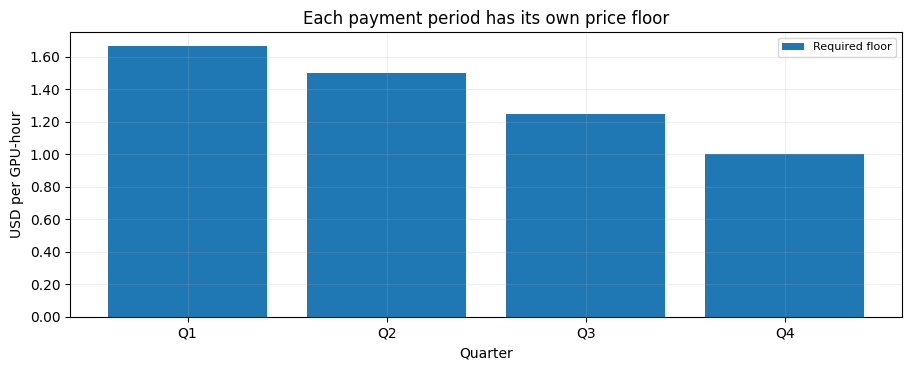

In [4]:
required_cash = [2_000_000, 1_800_000, 1_500_000, 1_200_000]
quarter_hours = 1_200_000
stress_indices = [1.00, 1.20, 1.40, 0.80]
quarter_strikes = [cash / quarter_hours for cash in required_cash]
rows = []
for quarter, (target, index) in enumerate(zip(required_cash, stress_indices), start=1):
    terms = revenue_floor_hedge_terms(
        required_revenue_usd=target, expected_gpu_hours=quarter_hours
    )
    receipt = european_option_payoff_usd(
        kind="put",
        settlement_price_usd_per_gpu_hour=index,
        strike_usd_per_gpu_hour=terms.strike_usd_per_gpu_hour,
        covered_gpu_hours=terms.notional_gpu_hours,
    )
    rows.append(
        [
            f"Q{quarter}",
            f"{terms.strike_usd_per_gpu_hour:.6f}",
            index,
            target,
            receipt,
            index * quarter_hours + receipt,
        ]
    )
show_finance_table(
    [
        "Quarter",
        "Strike USD/h",
        "Index USD/h",
        "Required USD",
        "Put USD",
        "Receipts + put USD",
    ],
    rows,
)
quarter_chart = plot_finance_series(
    {"Required floor": quarter_strikes},
    title="Each payment period has its own price floor",
    ylabel="USD per GPU-hour",
    xlabel="Quarter",
    x_values=[1, 2, 3, 4],
    x_tick_labels=["Q1", "Q2", "Q3", "Q4"],
    bar=True,
)
quarter_chart.axes[0].yaxis.set_major_formatter(StrMethodFormatter("{x:.2f}"))
display(quarter_chart)

In Q1, customers pay `1.2 million hours × USD 1 = USD 1.2 million`. Priya needs USD 2 million, so the put adds the missing **USD 800,000**. In Q3, sales produce USD 1.68 million, already above the USD 1.5 million requirement. That put pays zero, and Priya keeps the extra receipts. These totals are before option premiums.

**Why four puts instead of one annual put?** With an annual-average option, a later high price can offset an earlier low price before the payout is calculated. An end-of-year payout also arrives too late for a bill due in March. Separate quarterly puts test each quarter on its own.

The payment dates still matter. If Priya must pay monthly bills before a quarterly put pays, she needs money to bridge that gap. The puts also do not replace receipts from hours she fails to sell, and buying them costs money.

**What Priya would ask a dealer to quote:** four quarterly-average puts, each covering 1.2 million hours. Specify each calculated strike without rounding, the index averaging rules, and payment dates at months 3, 6, 9 and 12.

## 3. Rosa, the operator: pay less for a floor by giving up some upside

**Product:** Collar

**What Rosa is worried about:** “Below USD 1.75 per paid hour I cannot cover my modeled costs. I want protection, but buying a put costs money.”

**What she wants to protect:** A USD 1.75 minimum receipt rate on her expected paid hours. She is willing to give up receipts above USD 3.50 per hour to help pay for that protection.

**How the hedge helps:** Rosa buys a put that pays below 1.75 and sells a call that requires her to pay above 3.50. The money she receives for selling the call helps pay for the put. This combination is a **collar**.

**The payment steps — Rosa buys a put and sells a call.**

1. **Exchange premiums at the start.** Rosa pays the put seller **0.20 per covered hour** and receives **0.12 per covered hour** from the call buyer. Her net cost is **0.08 per hour**, or **USD 280,320** on **3,504,000 hours**. These premiums are teaching assumptions.
2. **Agree two different obligations on the same hours.** The purchased put has a **1.75 strike**; the sold call has a **3.50 strike**. Both use the annual-average index and pay at year-end. Customer rental payments remain separate.
3. **At year-end, determine who owes money:**

| Annual-average index | Put payment | Call payment | Customer receipts plus put minus call, per covered hour |
|---|---|---|---|
| **1.00**: below the floor | Put seller pays Rosa **0.75/hour** | Zero | `1.00 + 0.75 = 1.75` |
| **2.50**: between the strikes | Zero | Zero | **2.50** |
| **4.50**: above the cap | Zero | Rosa pays call buyer **1.00/hour** | `4.50 − 1.00 = 3.50` |

4. **Subtract the premium cost to assess the full result.** The 1.75–3.50 receipt range becomes **1.67–3.42 per hour after the 0.08 net premium**. Premiums moved at the start; this subtraction allocates their cost across the covered hours.

Selling the call is a payment promise. Rosa cannot decline its payout because she would prefer to keep the high rental price. The call buyer receives money under this example, not computing service.

Rosa's supplied inputs:

| Input | Supplied value | Meaning |
|---|---|---|
| `gpu_count`, `utilization` | 500 GPUs; 80% paid utilization | Expected paid share of available capacity |
| `months`, `hours_per_month` | 12 months; 730 hours/GPU/month | Covered service period |
| `floor`, `cap` | 1.75; 3.50 USD/GPU-hour | Put strike and sold-call strike |

**Added teaching assumptions:** Rosa's customers pay the same index used by both options, and she sells exactly the hedged quantity. Both options use the annual average price and pay at year-end. Each table row uses a constant price for that year.

To show the cost, assume Rosa pays **USD 0.20 per covered hour** for the put and receives **USD 0.12 per covered hour** for selling the call. Both premiums change hands at the start. These are invented teaching prices.

**First, count the hours.** `500 GPUs × 80% paid utilization × 730 hours × 12 months = 3,504,000 billed hours`. Each option covers all those hours.

**Next, calculate receipts per hour.** Start with the customer's payment. Add any put payout below 1.75, then subtract any call payment above 3.50:

`effective receipts = index + max(1.75 − index, 0) − max(index − 3.50, 0)`

**Finally, subtract the cost of protection.** Rosa pays 0.20 and receives 0.12, so her net premium is `0.20 − 0.12 = USD 0.08 per hour`. Across 3,504,000 hours, that costs **USD 280,320**. A **zero-cost collar** would require the two premiums to be equal; it would still give up receipts above the cap.

| Index USD/h | Put USD | Sold call USD | Before premium USD/h | After premium USD/h |
| --- | --- | --- | --- | --- |
| 1.00 | 2,628,000.00 | 0.00 | 1.75 | 1.67 |
| 1.75 | 0.00 | 0.00 | 1.75 | 1.67 |
| 2.50 | 0.00 | 0.00 | 2.50 | 2.42 |
| 3.50 | 0.00 | 0.00 | 3.50 | 3.42 |
| 4.50 | 0.00 | -3,504,000.00 | 3.50 | 3.42 |

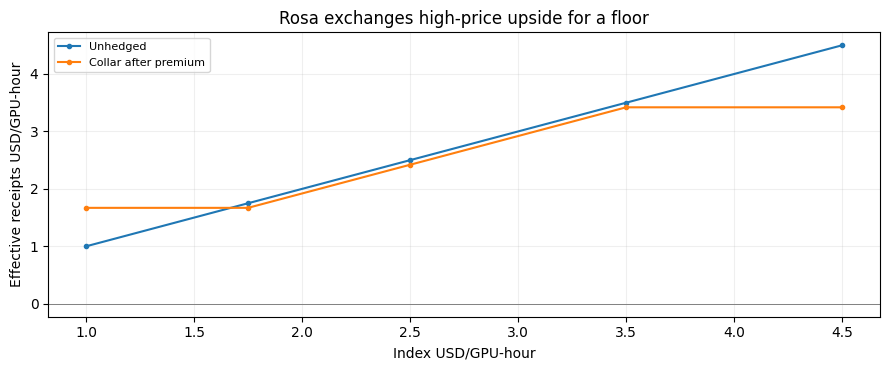

In [5]:
gpu_count, utilization = 500, 0.80
months, hours_per_month = 12, 730
floor, cap = 1.75, 3.50
put_premium, call_premium = 0.20, 0.12
collar_hours = gpu_count * utilization * months * hours_per_month
net_premium = (put_premium - call_premium) * collar_hours
rows, effective_rates = [], []
for index in [1.00, 1.75, 2.50, 3.50, 4.50]:
    put = european_option_payoff_usd(
        kind="put",
        settlement_price_usd_per_gpu_hour=index,
        strike_usd_per_gpu_hour=floor,
        covered_gpu_hours=collar_hours,
    )
    call_paid = european_option_payoff_usd(
        kind="call",
        settlement_price_usd_per_gpu_hour=index,
        strike_usd_per_gpu_hour=cap,
        covered_gpu_hours=collar_hours,
    )
    combined = index * collar_hours + put - call_paid
    effective_rates.append((combined - net_premium) / collar_hours)
    rows.append(
        [index, put, 0.0 - call_paid, combined / collar_hours, effective_rates[-1]]
    )
show_finance_table(
    [
        "Index USD/h",
        "Put USD",
        "Sold call USD",
        "Before premium USD/h",
        "After premium USD/h",
    ],
    rows,
)
display(
    plot_finance_series(
        {"Unhedged": [1, 1.75, 2.5, 3.5, 4.5], "Collar after premium": effective_rates},
        title="Rosa exchanges high-price upside for a floor",
        ylabel="Effective receipts USD/GPU-hour",
        xlabel="Index USD/GPU-hour",
        x_values=[1, 1.75, 2.5, 3.5, 4.5],
    )
)

At a **USD 1** index, Rosa's put pays `0.75 × 3,504,000 = USD 2,628,000`. Combined with customer receipts, that gives her USD 1.75 per hour before premium. At a **USD 4.50** index, she pays `1.00 × 3,504,000 = USD 3,504,000` on the sold call, leaving USD 3.50 per hour before premium.

Subtracting the USD 0.08 net premium lowers the range to **USD 1.67–3.42 per hour**. At the low end, Rosa is now below her USD 1.75 cost threshold. A put struck at break-even does not also pay for its own purchase cost.

The source ideas mention **USD 3.62** as another possible call strike. We retain it as a candidate to ask a dealer about. We cannot tell from the business inputs whether either 3.50 or 3.62 would pay for the put in full. The actual quoted premiums determine that.

Selling the call also creates a payment obligation on the original quantity. If Rosa sells fewer physical hours but prices rise above the cap, she may owe call payments without enough matching customer income.

**What Rosa would ask a dealer to quote:** a 1.75 put and a 3.50 call on the same 3,504,000 hours and annual price average. She can also ask which call strike, if any, would make the two premiums equal. Then compare the money saved today with the receipts given up above that cap.

## 4. Sam, the operator: wait for a customer's renewal decision

**Product:** Swaption

**What Sam is worried about:** “My customer may renew in twelve months. If they leave, I will need to find new customers at whatever rental prices are available. I want protection for that possibility, but I do not want to commit to a swap today that I may not need.”

**What he wants to protect:** The ability to secure a USD 2 selling rate for the following year's expected rentals if he chooses to do so at month 12.

**How the hedge helps:** Sam buys the right to enter a swap later. This is a **swaption**, an option on a swap. At month 12 he can **exercise**, meaning use the right, or let it expire. If he exercises, the resulting swap can require him to make payments as well as receive them.

**The payment steps — Sam first buys a choice; exercising it creates a swap.**

1. **Buy the right now.** Sam pays the swaption seller an option premium, still to be quoted. It buys the right to enter a **receive-fixed-2.00/pay-floating** swap at **month 12**. Buying the right does not start the swap today.
2. **Choose at month 12.** Sam can exercise the right or let it expire. If a new swap then offers only 1.50, his right to receive 2.00 can be useful. This decision happens before the later rental index is known. If he lets the right expire, no swap is created and he cannot revive it later. The premium is spent either way.
3. **If exercised, make the monthly swap payments.** For months **13–24**, the swap covers **1,168,000 GPU-hours per month**, or **14,016,000** in total. The counterparty owes Sam 2.00 per covered hour; Sam owes the monthly index. Only the difference changes hands. At index **1.00**, the counterparty pays Sam **USD 1,168,000 that month**. At **2.50**, Sam pays it **USD 584,000**. At 2.00, neither pays a difference.
4. **Combine the swap with separate customer receipts.** If Sam sells the matching hours at the index, receipts plus the swap leave **2.00 per covered hour before premium**. Once exercised, the swap is binding: Sam cannot skip a month that would require him to pay.

The swaption provides the initial choice. It is not a series of choices to accept only favorable swap payments, and it does not itself supply replacement customers.

Sam's supplied inputs:

| Input | Supplied value | Meaning |
|---|---|---|
| `gpu_count` | 2,000 | GPUs exposed if the customer leaves |
| `utilization` | 80% | Planned billed share after nonrenewal |
| `months`, `hours_per_month` | 12 months; 730 hours/GPU/month | Following year's service window |
| `fixed_rate` | 2.00 USD/GPU-hour | Fixed rate in the swap Sam could choose to enter |

**Added teaching assumptions:** there is one decision date, month 12. Exercise creates a swap for service months 13–24, with equal monthly quantities and payments at each month-end. It pays cash rather than delivering GPUs. If the customer leaves, Sam expects to sell the covered hours at the swap's index price.

**Find the quantity first.** `2,000 GPUs × 80% × 730 hours × 12 months = 14,016,000 GPU-hours`. That is the total quantity covered by the swap Sam could enter.

**Keep the decision price separate from the later outcome.** At month 12, Sam can observe a **forward quote**: a rate offered then for the following year's swap. The table tests quotes of 1.50 and 2.50. The actual index during the following year is still unknown when he chooses. We separately test later prices of 1.00 and 2.50, held constant for the year.

Once Sam enters the swap, its total cash is `14,016,000 × (2.00 − later index)`. A lower index produces a receipt; a higher index produces a payment. The table calculates those future swap payments. It does not calculate what Sam should pay today to buy the swaption; that premium is unknown.

In [6]:
gpu_count, utilization = 2_000, 0.80
months, hours_per_month, fixed_rate = 12, 730, 2.00
swaption_hours = gpu_count * utilization * months * hours_per_month
rows = []
# Exercise choices are specified at month 12, before the later index is known.
for forward_at_exercise, exercise, later_index in [
    (1.50, True, 1.00),
    (1.50, True, 2.50),
    (2.50, False, 1.00),
]:
    receipt = 0.0
    if exercise:
        settlements = forward_settlements_usd(
            benchmark_usd_per_gpu_hour=[later_index] * months,
            strike_usd_per_gpu_hour=fixed_rate,
            hedge_gpu_hours=[swaption_hours / months] * months,
            settlement_months=list(range(13, 25)),
            side="seller",
        )
        receipt = sum(row.amount_usd for row in settlements)
    rows.append(
        [
            forward_at_exercise,
            "Yes" if exercise else "No",
            later_index,
            receipt,
            later_index * swaption_hours + receipt,
        ]
    )
show_finance_table(
    [
        "Month-12 forward USD/h",
        "Exercise?",
        "Later index USD/h",
        "Swap USD",
        "Sales + swap USD",
    ],
    rows,
)

| Month-12 forward USD/h | Exercise? | Later index USD/h | Swap USD | Sales + swap USD |
| --- | --- | --- | --- | --- |
| 1.50 | Yes | 1.00 | 14,016,000.00 | 28,032,000.00 |
| 1.50 | Yes | 2.50 | -7,008,000.00 | 28,032,000.00 |
| 2.50 | No | 1.00 | 0.00 | 14,016,000.00 |

Suppose the customer leaves and, at month 12, a new swap would offer a fixed rate of only **USD 1.50**. Sam's right to receive **USD 2** is useful. He exercises it before knowing next year's actual prices.

If the following year's index is **USD 1**, customers pay USD 14.016 million and the swap pays another USD 14.016 million. If the index is **USD 2.50**, customers pay USD 35.04 million but Sam pays USD 7.008 million on the swap. Either way, he receives **USD 28.032 million in total**, before premium, if he sells all the planned hours at the index.

The last row makes a different decision at month 12. A new forward quote offers 2.50, so Sam lets his right to receive 2.00 expire and does not buy replacement protection. The index later falls to 1.00. He cannot revive the expired option after seeing that outcome. Once he exercises, he must honor the swap; once he lets the right expire, he cannot use it later.

If the customer renews, Sam may no longer need this hedge for rental income. The option could still be valuable, but any right to sell it or receive cash for it depends on its terms. Renewal does not automatically cancel an ordinary swaption.

**What Sam would ask a dealer to quote:** the right, exercisable at month 12, to enter the 2.00 swap on the specified monthly quantities for months 13–24. Pricing that right needs market information about future rates and how much they might change. The future swap payments above are not the price Sam pays to buy the right today.

## 5. Taylor, the reseller: protect the difference between two changing rates

**Product:** Tenor spread swap

**What Taylor is worried about:** “My selling price and purchase price both change. Even if neither moves very far, I could lose most of my earnings if the gap between them shrinks.”

**What Taylor wants to protect:** A USD 0.25 difference per hour between the two reference rates. After a separate USD 0.10 purchase fee, that would leave USD 0.15 per hour before other business costs.

**How the hedge helps:** The swap pays Taylor when the reference-price difference is below 0.25. Taylor pays the counterparty when it is above 0.25. Combined with the business receipts and purchase payments, this fixes that difference on the covered hours.

A **spread** is one price minus another. Here **1M** means a one-month rental commitment and **12M** means a twelve-month rental commitment. Taylor sells at the 1M index and buys at the 12M index plus a fee. Both of Taylor's contract rates reset each month in this example. This differs from Alex's already-fixed purchase cost.

**The payment steps — Taylor receives a fixed spread and pays a floating spread.**

1. **Agree the terms.** Taylor and the counterparty fix a **0.25 USD/GPU-hour spread** on **58,400 GPU-hours each month for 12 months**. This example includes no upfront swap payment.
2. **Keep trading capacity separately.** Customers pay Taylor the 1M index; Taylor pays the capacity supplier the 12M index plus **0.10 per hour**. Both indices change each month. These physical contracts already produce the changing business spread.
3. **Calculate the swap's two legs each month.** A **leg** is one side of the swap's payment calculation:

| Swap leg | Taylor's side of the payment | Rate per covered GPU-hour |
|---|---|---|
| Fixed leg | Taylor receives this amount | **USD 0.25**, unchanged throughout the swap |
| Floating leg | Taylor pays this amount | **1M rental index − 12M rental index**, recalculated each month |

The floating amount is the **difference between the two indices**, not either rental index by itself. For example, if the 1M index is 4.75 and the 12M index is 4.70, the floating spread is 0.05. Taylor receives 0.25 and pays 0.05, leaving a **net swap receipt of USD 0.20 per covered hour**. If the floating spread is 0.30, Taylor receives 0.25 and pays 0.30, so Taylor instead owes **USD 0.05 per covered hour**.

4. **Pay only the difference at month-end.** At a 0.05 floating spread, the counterparty owes Taylor `58,400 × 0.25 = USD 14,600` on the fixed leg, and Taylor owes `58,400 × 0.05 = USD 2,920` on the floating leg. They net the amounts: **the counterparty sends Taylor USD 11,680**. At a 0.30 spread, **Taylor sends the counterparty USD 2,920** instead. At exactly 0.25, no swap payment is due.

The formula from Taylor's perspective is `monthly covered hours × [0.25 − (1M index − 12M index)]`. A negative floating spread is allowed: subtracting it increases Taylor's receipt. The later results show that case.

**Why this offsets the business risk.** Taylor's actual capacity sales and purchases already earn the floating spread, less the 0.10 purchase fee. The swap removes that floating spread and replaces it with 0.25:

`business spread − purchase fee + swap receipt per hour = floating spread − 0.10 + (0.25 − floating spread) = USD 0.15`.

Taylor still pays the capacity supplier and collects from customers under separate physical contracts. The swap counterparty pays or receives only the financial difference.

Taylor's supplied inputs:

| Input | Supplied value | Meaning |
|---|---|---|
| Sale / purchase indices | 5.30 / 5.00 initially; 4.75 / 4.70 stressed | USD/GPU-hour for 1M and 12M tenors |
| `fixed_spread` | 0.25 USD/GPU-hour | Target difference locked by the swap |

**Added teaching assumptions:** Taylor buys and sells the same quantity: 100 GPUs at 80% paid utilization for 12 months, with 730 hours a month. The purchase fee, `purchase_basis`, is USD 0.10 per hour. Both rates and the swap use matching monthly index observations and month-end cash dates. Each scenario keeps its two index rates constant through the year.

The index's **tenor** describes the length of rental commitment represented by its price. It does not dictate when Taylor's own invoice changes. We explicitly assume monthly price resets here.

**Calculate the hours:** `100 × 80% × 730 × 12 = 700,800 GPU-hours`.

**Calculate the market spread:** at the initial prices, `5.30 − 5.00 = USD 0.30 per hour`. In the stressed case, `4.75 − 4.70 = USD 0.05`.

**Calculate what the swap adds or takes away:** `700,800 × (0.25 − market spread)`. At a 0.05 spread it adds 0.20 per hour. At a 0.30 spread Taylor pays 0.05 per hour. Either way, the reference-price difference becomes 0.25. Subtract the 0.10 purchase fee to leave **USD 0.15 per hour**.

In [7]:
spread_hours = 100 * 0.80 * 730 * 12
fixed_spread, purchase_basis = 0.25, 0.10
rows = []
for sale_index, purchase_index in [(5.30, 5.00), (4.75, 4.70), (4.50, 4.70)]:
    market_spread = sale_index - purchase_index
    physical_margin = (market_spread - purchase_basis) * spread_hours
    receipt = spread_swap_settlement_usd(
        sale_index_usd_per_gpu_hour=sale_index,
        purchase_index_usd_per_gpu_hour=purchase_index,
        fixed_spread_usd_per_gpu_hour=fixed_spread,
        covered_gpu_hours=spread_hours,
    )
    rows.append(
        [
            sale_index,
            purchase_index,
            market_spread,
            physical_margin,
            receipt,
            physical_margin + receipt,
        ]
    )
show_finance_table(
    [
        "Sale USD/h",
        "Purchase index USD/h",
        "Spread USD/h",
        "Physical margin USD",
        "Swap USD",
        "Combined USD",
    ],
    rows,
)

| Sale USD/h | Purchase index USD/h | Spread USD/h | Physical margin USD | Swap USD | Combined USD |
| --- | --- | --- | --- | --- | --- |
| 5.30 | 5.00 | 0.30 | 140,160.00 | -35,040.00 | 105,120.00 |
| 4.75 | 4.70 | 0.05 | -35,040.00 | 140,160.00 | 105,120.00 |
| 4.50 | 4.70 | -0.20 | -210,240.00 | 315,360.00 | 105,120.00 |

When the index spread is **USD 0.30**, Taylor pays `0.05 × 700,800 = USD 35,040` on the swap. When it falls to **USD 0.05**, the swap pays Taylor `0.20 × 700,800 = USD 140,160`. The amount left after the capacity purchase, fee and swap is **USD 105,120** in either case: `0.15 × 700,800`.

The third row buys at a higher index than it sells at, creating a negative floating spread of −0.20. In the swap formula, subtracting −0.20 adds 0.20 to the fixed 0.25 receipt. Taylor therefore receives 0.45 per covered hour, restoring the same modeled business result. Taylor still has other business costs to pay from the USD 105,120.

This works because the quantities, reference prices and payment periods match. Paying for more hours than customers buy, paying a different rate from the reference index, or facing a higher fee would leave a gap.

**What Taylor would ask a dealer to quote:** a swap covering 58,400 GPU-hours per month for 12 months, targeting a 0.25 spread between the named B300 1M and 12M indices. The contract must say exactly how and when each index is measured. The target spread still needs a dealer quote.

## 6. Morgan, the GPU owner: protect what remains after electricity costs

**Product:** Compute and power swaps

**What Morgan is worried about:** “Customers may pay less for compute while electricity gets more expensive. Protecting my rental rate alone would still leave me exposed to a larger power bill.”

**What Morgan wants to protect:** USD 1 per billed GPU-hour after paying for electricity and the other operating costs in this example. Across 10 million billed hours, that means USD 10 million left over.

**How the hedges help:** One swap offsets falling compute rental prices. A second offsets rising electricity prices. If prices move in Morgan's favor instead, the swaps require payments. Together they stabilize the two price components of the business's margin.

**The payment steps — Morgan receives fixed on compute but pays fixed on power.**

1. **Agree two swaps for the modeled year.** The compute swap covers **10 million GPU-hours** and the power swap covers **7,000 MWh**, each split equally across 12 monthly payments. A **MWh**, or megawatt-hour, is a unit of electricity; we derive the energy quantity below. This example includes no upfront swap payments.
2. **Keep paying the physical bills.** Customers pay Morgan the compute index. Morgan pays the electricity supplier the power index for electricity consumed. These payments continue regardless of the swaps.
3. **Calculate each swap at month-end.** The directions differ because Morgan sells compute but buys power:

| Contract | Morgan receives | Morgan pays | Net swap receipt to Morgan |
|---|---|---|---|
| Compute swap | Fixed **1.442 USD/GPU-hour** | Floating compute index | `GPU-hours × (1.442 − compute index)` |
| Power swap | Floating power index | Fixed **60 USD/MWh** | `MWh × (power index − 60)` |

Each swap pays only the difference between its two sides. At a **1.20 compute index**, the compute counterparty pays Morgan **0.242 per covered GPU-hour**; at **2.00**, Morgan pays it **0.558 per hour**. At a **100 power index**, the power counterparty pays Morgan **40 per covered MWh**; at **40**, Morgan pays it **20 per MWh**. At either swap's fixed rate, that swap pays zero.

4. **Combine receipts and bills.** Customer compute receipts plus the compute swap give **1.442 per covered GPU-hour**. Electricity bills minus the power-swap receipts cost **60 per covered MWh**. Subtract that electricity cost and the other stated operating costs to find the remaining margin. The two counterparties need not be the same business.

These are the example's target fixed rates; we derive the compute target below. The power swap sends cash to Morgan, not electricity. Morgan must still pay the electricity supplier's actual invoice.

Morgan owns the equipment and pays electricity separately. **Margin** here means receipts minus electricity and the stated other running costs. The USD 1 target is before equipment purchase costs, loan payments, taxes and any hedge premiums. A reseller whose rental bill already includes electricity should not add this power cost again.

Morgan's inputs:

| Input | Value and origin | Meaning |
|---|---|---|
| `compute_hours` | 10m GPU-hours, supplied | Paid hours in the modeled year |
| `kwh_per_hour` | 0.7 kWh/GPU-hour, supplied | Assumed total electricity per billed GPU-hour |
| `target_margin` | 1.00 USD/GPU-hour, supplied | Desired margin after stated operating costs |
| `fixed_power_rate` | 60 USD/MWh, added | Hypothetical power-swap rate |
| `other_cost` | 0.40 USD/GPU-hour, added | Non-power cost, assumed constant |

**First, put the power quantity in the right units.** A **kilowatt-hour (kWh)** measures energy. One **megawatt-hour (MWh)** is 1,000 kWh. The power price is quoted per MWh, so convert `0.7 ÷ 1,000 = 0.0007 MWh per billed GPU-hour`. Across 10 million billed hours, this is **7,000 MWh**.

**Next, find the compute rate needed to meet the target.** At the assumed fixed power rate, electricity costs `0.0007 × USD 60 = USD 0.042 per GPU-hour`. Add the USD 0.40 other costs and the USD 1 Morgan wants to keep: `1.00 + 0.042 + 0.40 = USD 1.442 per GPU-hour`.

**The swaps point in opposite directions because one protects revenue and the other protects a cost.** The compute swap pays Morgan `covered GPU-hours × (1.442 − compute index)`. The power swap pays Morgan `covered MWh × (power index − 60)`. A high electricity price therefore produces money to help pay a high electricity bill.

**Added teaching assumptions:** each physical price equals its hedge index. Quantities and scenario prices stay constant, and all cash settles monthly; the table shows yearly totals. We test compute/power prices of 1.20 USD per GPU-hour and 100 USD/MWh, then 2.00 and 40.

The assumed 0.7 kWh per billed hour includes a share of electricity used while GPUs are idle and by supporting equipment. It is a teaching assumption, not a measured hardware specification. Actual electricity use may not fall as quickly as billed hours.

In [8]:
compute_hours, kwh_per_hour = 10_000_000, 0.7
target_margin, fixed_power_rate, other_cost = 1.00, 60.0, 0.40
mwh_per_hour = kwh_per_hour / 1_000
energy_mwh = compute_hours * mwh_per_hour
fixed_compute_rate = target_margin + mwh_per_hour * fixed_power_rate + other_cost
rows = []
for compute_index, power_index in [(1.20, 100.0), (2.00, 40.0)]:
    physical_margin = compute_hours * (
        compute_index - mwh_per_hour * power_index - other_cost
    )
    compute_receipt = sum(
        row.amount_usd
        for row in forward_settlements_usd(
            benchmark_usd_per_gpu_hour=[compute_index] * 12,
            strike_usd_per_gpu_hour=fixed_compute_rate,
            hedge_gpu_hours=[compute_hours / 12] * 12,
            settlement_months=list(range(1, 13)),
            side="seller",
        )
    )
    power_receipt = power_swap_receipt_usd(
        energy_mwh=energy_mwh,
        market_usd_per_mwh=power_index,
        fixed_usd_per_mwh=fixed_power_rate,
    )
    rows.append(
        [
            compute_index,
            power_index,
            physical_margin,
            compute_receipt,
            power_receipt,
            physical_margin + compute_receipt + power_receipt,
        ]
    )
print(
    f"Power hedge: {energy_mwh:,.0f} MWh; target compute rate: {fixed_compute_rate:.3f} USD/GPU-hour"
)
show_finance_table(
    [
        "Compute USD/h",
        "Power USD/MWh",
        "Physical margin USD",
        "Compute swap USD",
        "Power swap USD",
        "Combined margin USD",
    ],
    rows,
)

Power hedge: 7,000 MWh; target compute rate: 1.442 USD/GPU-hour


| Compute USD/h | Power USD/MWh | Physical margin USD | Compute swap USD | Power swap USD | Combined margin USD |
| --- | --- | --- | --- | --- | --- |
| 1.20 | 100.00 | 7,300,000.00 | 2,420,000.00 | 280,000.00 | 10,000,000.00 |
| 2.00 | 40.00 | 15,720,000.00 | -5,580,000.00 | -140,000.00 | 10,000,000.00 |

In the first row, low compute prices and expensive power leave Morgan **USD 7.30 million** before the hedges. The compute swap adds USD 2.42 million; the power swap adds USD 0.28 million. Together they reach the **USD 10 million target**, or USD 1 per billed hour.

In the second row, higher compute prices and cheaper power leave USD 15.72 million before the hedges. Morgan then pays USD 5.58 million on the compute swap and USD 0.14 million on the power swap. The final margin is again USD 10 million. The swaps give up favorable price changes as well as offsetting unfavorable ones.

This result depends on the power index matching the electricity price Morgan actually pays. A **wholesale** index describes electricity before some delivery charges; Morgan's bill may also include network fees or **demand charges**, fees based on peak power use. Changes in electricity consumption, other costs or cash dates can also leave a gap.

**What Morgan would ask a dealer to quote:** a compute swap targeting 1.442 on 10 million annual GPU-hours, and a power swap targeting 60 on 7,000 MWh, each split into matching monthly quantities. Those rates are the business's targets, not confirmed dealer offers.

## 7. Dana, the project owner: leave enough cash for the loan payments

**Product:** Financing-linked put

**What Dana is worried about:** “I want to borrow USD 300 million to buy USD 500 million of GPUs. Some customer receipts are fixed, but the rest depend on future rental prices. If those prices fall, I may not have enough left after operating bills to pay the lender.”

**What Dana wants to protect:** USD 25 million of cash after operating costs in a quarter when loan payments are USD 20 million. That leaves a USD 5 million cushion.

**How the hedge helps:** First subtract the receipts already promised by fixed-price customers. Then calculate the rental rate needed from the remaining expected hours. A put can fill a shortfall caused by a lower index price on those hours.

**The payment steps — Dana buys a price put; the loan remains a separate obligation.**

1. **Buy the put.** Dana pays a premium to the option seller for a **2.875 strike on 8 million GPU-hours** in the modeled quarter. The cash target determines this strike, as shown below. The premium is unknown and excluded from the results.
2. **Keep the customer contracts.** Fixed-price customers pay **USD 12 million**. Other customers pay the floating compute index on the hours they buy. The put does not rewrite either customer's bill.
3. **Settle at quarter-end using the quarter's average index.** Below 2.875, the option seller pays Dana `8 million × (2.875 − average index)`. At **1.50**, that is **USD 11 million**. At or above 2.875, the payment is zero; Dana owes no high-price difference to the option seller.
4. **Use the combined cash for bills and debt.** With all 8 million hours sold at 1.50, Dana collects **12m fixed receipts + 12m floating receipts + 11m put = USD 35m**. Dana pays **USD 10m operating bills**, leaving **USD 25m** for the **USD 20m loan payment** and USD 5m cushion, before premium.

“Financing-linked” describes how we size the put. Its payment trigger is a low compute index, not a missed loan payment or a lender's loss. The option seller is not taking over Dana's debt.

**DSCR**, the debt-service coverage ratio, compares cash available for loan payments with the loan payments due. A target of **1.25** means USD 1.25 available for every USD 1 owed. **Merchant** hours are sold at market prices rather than at prices already fixed by customer contracts.

Dana's project owns the GPUs. Those assets may support a loan as **collateral**, property a lender has agreed rights over. Purchasing rental access alone would not give a reseller ownership of that equipment.

Dana's inputs:

| Input | Value and origin | Meaning |
|---|---|---|
| `asset_cost`, `loan_requested` | USD 500m; 300m, supplied | Purchase and requested borrowing, not payment amounts |
| `target_dscr` | 1.25, supplied | Desired operating-cash cushion |
| `debt_service` | USD 20m, added | One quarter's interest plus principal due |
| `operating_cost` | USD 10m, added | All modeled operating cash paid that quarter |
| `contracted_receipts` | USD 12m, added | Gross customer cash from separate fixed-price contracts |
| `merchant_hours` | 8m GPU-hours, added | Additional billed market-rate hours in that quarter |

**Added teaching assumptions:** the quarter's loan payment is USD 20 million. A USD 300 million loan balance alone cannot tell us that payment; we would also need the interest rate and repayment schedule. All customer, hedge, operating and loan cash occurs at quarter-end here. The lender is assumed to count hedge receipts in its DSCR calculation. Premiums are not included.

**Work backward from the cash Dana needs:**

1. The lender's cushion requires `1.25 × USD 20 million = USD 25 million` after operating bills.
2. Add USD 10 million of operating bills. Total receipts must be **USD 35 million**.
3. Existing fixed-price customers supply USD 12 million. The remaining sales and hedge must supply `35 − 12 = USD 23 million`.
4. Divide that amount across 8 million expected merchant hours: `23 million ÷ 8 million = USD 2.875 per hour`. That is the put strike.

The USD 12 million is customer cash **before** deducting operating costs. Using a number already net of those costs would subtract the same costs twice. If fixed customer receipts already cover the target, no additional price floor is needed for this test. If Dana has a cash gap but no hours to sell, dividing by hours cannot produce a useful price target.

**Real-deal connection:** CoreWeave's [Q2 2026 debt note, DDTL 5.0](https://www.sec.gov/Archives/edgar/data/1769628/000176962826000366/R16.htm) describes a requirement for interest-rate swaps covering at least 95% of the expected remaining balances on floating-rate loans, within specified time limits. A floating-rate loan has interest payments that change with a reference rate. Those swaps protect against borrowing-rate changes. Our compute-price put addresses a different risk and is not presented as that facility's required hedge.

In [9]:
asset_cost, loan_requested = 500_000_000, 300_000_000
target_dscr, debt_service = 1.25, 20_000_000
operating_cost, contracted_receipts, merchant_hours = 10_000_000, 12_000_000, 8_000_000
required_merchant_cash = max(
    target_dscr * debt_service + operating_cost - contracted_receipts, 0
)
floor_rate = required_merchant_cash / merchant_hours
requirement = financing_hedge_requirement(
    target_dscr=target_dscr,
    debt_service_usd=debt_service,
    operating_cost_usd=operating_cost,
    contracted_receipts_usd=contracted_receipts,
    merchant_gpu_hours=merchant_hours,
)
print(f"Loan / purchase price: {loan_requested / asset_cost:.0%}")
print(f"Purchase equity before fees/reserves: USD {asset_cost - loan_requested:,.0f}")
print(
    f"Merchant cash target: USD {required_merchant_cash:,.0f}; put strike: {floor_rate:.3f} USD/h"
)
rows = []
for index, actual_hours in [
    (1.50, merchant_hours),
    (4.00, merchant_hours),
    (4.00, merchant_hours / 2),
]:
    put = european_option_payoff_usd(
        kind="put",
        settlement_price_usd_per_gpu_hour=index,
        strike_usd_per_gpu_hour=floor_rate,
        covered_gpu_hours=requirement.notional_gpu_hours,
    )
    cash_available = contracted_receipts + index * actual_hours + put - operating_cost
    dscr = debt_service_coverage(
        cfads_usd=cash_available, debt_service_usd=debt_service
    )
    rows.append([index, actual_hours, put, cash_available, dscr])
show_finance_table(
    ["Index USD/h", "Actual merchant hours", "Put USD", "Cash available USD", "DSCR"],
    rows,
)

Loan / purchase price: 60%
Purchase equity before fees/reserves: USD 200,000,000
Merchant cash target: USD 23,000,000; put strike: 2.875 USD/h


| Index USD/h | Actual merchant hours | Put USD | Cash available USD | DSCR |
| --- | --- | --- | --- | --- |
| 1.50 | 8,000,000.00 | 11,000,000.00 | 25,000,000.00 | 1.25 |
| 4.00 | 8,000,000.00 | 0.00 | 34,000,000.00 | 1.70 |
| 4.00 | 4,000,000.00 | 0.00 | 18,000,000.00 | 0.90 |

At **USD 1.50** with all 8 million merchant hours sold, those sales bring in USD 12 million. The put adds **USD 11 million**. Add the separate USD 12 million of fixed-price customer receipts, then pay USD 10 million of operating bills: `12 + 11 + 12 − 10 = USD 25 million` remains.

Dana owes USD 20 million on the loan, so DSCR is `25 ÷ 20 = 1.25`. At a USD 4 index with all hours sold, cash available for the loan is USD 34 million. DSCR rises to **1.70**, and the put pays nothing.

The third row keeps the USD 4 price but sells only half the merchant hours. Now only USD 18 million remains for the USD 20 million loan payment: **DSCR is 0.90**. The put still pays zero because its index is above the strike. A high price does not help enough if too few hours sell. Operating costs stay fixed in this experiment; a fuller budget would distinguish costs that change with usage from those that do not.

The requested USD 300 million loan covers 60% of the USD 500 million purchase. Dana would need USD 200 million of **equity**, money supplied by the project's owners, plus any fees and required cash reserves. This calculation does not establish how much a lender will agree to lend.

**What Dana would ask a dealer to quote:** a put on the quarter's average index, struck at 2.875 on 8 million merchant hours. Dana would give the lender its price, payment dates and counterparty terms along with the loan schedule. Whether those hedge receipts count in the lender's cash test must be agreed.

## 8. Noor, the operator: find someone to pay for hours, then protect their price

**Product:** Quantity backstop plus put

**What Noor is worried about:** “A put can pay when rental prices fall, but it does not bring me customers. I need someone to commit to paying for a minimum amount of capacity.”

**What Noor wants to protect:** Payment for at least 75% of the fleet's available hours. Existing customers already cover 60%, so Noor needs a buyer for another 15%. On those additional hours, Noor wants at least USD 2 per hour before fees and premium.

**How the protection helps:** A new buyer promises to pay for otherwise-unsold hours. Separately, a put protects the index-linked price that buyer pays. One contract addresses missing demand; the other addresses a low price.

**The payment steps — Noor arranges a paying buyer, then buys price protection.**

1. **Sign the purchase commitment.** Existing customers cover 60% of capacity. The backstop buyer promises to pay Noor for an additional **1,095,000 reserved GPU-hours per month**: **13.14 million over the year**, bringing paid coverage to 75%. These hours are otherwise unsold in this example. The buyer pays even if it does not use them, provided Noor makes the promised service available.
2. **Buy matching puts.** Noor pays option premiums for a **2.00 strike on those same monthly hours**. The option seller can be a different business from the backstop buyer. The premium and any fee for arranging the purchase commitment are unknown and excluded.
3. **Collect two separate month-end payments.** The backstop buyer pays `1,095,000 × monthly index` for the reserved service. If the index is below 2.00, the put seller separately pays `1,095,000 × (2.00 − index)`. At or above 2.00, the put pays zero; Noor owes no price-difference payment under the purchased put.
4. **Follow one month's money at index 1.50.** The buyer pays **USD 1,642,500**; the put seller pays **USD 547,500**. Noor receives **USD 2,190,000**, or **2.00 per protected hour before fees and premium**. Above 2.00, Noor keeps the higher buyer payment and receives nothing from the put.

The purchase commitment supplies the paid quantity. The put supplies money when the price is low. If the buyer fails to pay its invoice, the put still pays only its price-based amount; it does not reimburse the unpaid invoice.

A **quantity backstop** is a purchase commitment for specified otherwise-unsold capacity. Under the **take-or-pay** terms assumed here, the buyer pays for its reserved hours even if it does not use them, provided Noor makes the service available as agreed. Paid hours and busy GPUs are different things.

Noor's supplied inputs:

| Input | Supplied value | Meaning |
|---|---|---|
| `gpu_count` | 10,000 | Available GPUs |
| `contracted_fraction` | 60% | Already contracted capacity |
| `minimum_paid_fraction` | 75% | Desired minimum paid share of capacity |
| `floor` | 2.00 USD/GPU-hour | Desired rate on additional protected hours |

**Added teaching assumptions:** the period is 12 months, at 730 available hours per GPU per month. Existing customers pay fixed prices for their 60%. The new buyer pays the index for the additional hours, and Noor buys puts on that same index and quantity. Capacity is delivered as promised. Cash is paid monthly; the table adds the monthly results at a constant 1.50 index. The backstop fee and put premium are unknown and excluded.

**Start with all available hours:** `10,000 × 730 × 12 = 87.6 million GPU-hours`.

**Find the paid-hours target:** 75% of 87.6 million is **65.7 million hours**. Existing contracts already cover 60%, or **52.56 million hours**.

**Find the gap:** `65.7 million − 52.56 million = 13.14 million hours`. This is the new purchase commitment needed. It is also the put quantity because these additional hours have a floating price. We do not add the existing fixed-price hours to this hedge.

**Real-deal connection:** CoreWeave's [September 2025 Form 8-K, Item 1.01](https://www.sec.gov/Archives/edgar/data/1769628/000176962825000047/crwv-20250909.htm) reports NVIDIA's agreement to purchase residual unsold capacity through April 13, 2032, subject to delivery, availability and termination terms. That supports the backstop concept; Noor's fleet, percentages, price and put are our supplied/hypothetical example, not that agreement's disclosed terms.

In [10]:
gpu_count, contracted_fraction, minimum_paid_fraction = 10_000, 0.60, 0.75
months, hours_per_month, floor, index = 12, 730, 2.00, 1.50
available_hours = gpu_count * months * hours_per_month
existing_hours = available_hours * contracted_fraction
target_hours = available_hours * minimum_paid_fraction
incremental_hours = max(target_hours - existing_hours, 0)
backstop_receipts = incremental_hours * index
put_receipt = european_option_payoff_usd(
    kind="put",
    settlement_price_usd_per_gpu_hour=index,
    strike_usd_per_gpu_hour=floor,
    covered_gpu_hours=incremental_hours,
)
show_finance_table(
    ["Calculation", "Result"],
    [
        ["Available GPU-hours", available_hours],
        ["Existing paid GPU-hours", existing_hours],
        ["Target paid GPU-hours", target_hours],
        ["Incremental backstop / put GPU-hours", incremental_hours],
        ["Incremental backstop receipts USD", backstop_receipts],
        ["Put receipts USD", put_receipt],
        [
            "Incremental combined receipts USD, before fees",
            backstop_receipts + put_receipt,
        ],
    ],
)
show_finance_table(
    ["Promised backstop hours", "Remaining paid-hours gap"],
    [
        [quantity, max(target_hours - existing_hours - quantity, 0)]
        for quantity in [incremental_hours, incremental_hours / 2, 0]
    ],
)

| Calculation | Result |
| --- | --- |
| Available GPU-hours | 87,600,000.00 |
| Existing paid GPU-hours | 52,560,000.00 |
| Target paid GPU-hours | 65,700,000.00 |
| Incremental backstop / put GPU-hours | 13,140,000.00 |
| Incremental backstop receipts USD | 19,710,000.00 |
| Put receipts USD | 6,570,000.00 |
| Incremental combined receipts USD, before fees | 26,280,000.00 |

| Promised backstop hours | Remaining paid-hours gap |
| --- | --- |
| 13,140,000.00 | 0.00 |
| 6,570,000.00 | 6,570,000.00 |
| 0.00 | 13,140,000.00 |

The new buyer pays `13.14 million hours × USD 1.50 = USD 19.71 million`. The put adds `13.14 million × (2.00 − 1.50) = USD 6.57 million`. Together, Noor receives **USD 26.28 million** on these additional hours, equal to USD 2 per hour before the backstop fee and option premium.

That subtotal excludes the existing customers' 52.56 million hours: their fixed contract rate was not supplied. The new commitment fills only the gap between the original 60% paid capacity and the 75% target.

The second table asks what happens if the new buyer promises fewer hours. A commitment for only half the required amount leaves **6.57 million hours without a promised buyer**. The put cannot fill that demand gap. If the backstop buyer fails to pay, the put also does not replace the missing invoice merely because it is unpaid; it still follows its index-price formula.

**What Noor would ask to arrange:** first, a purchase commitment for the additional 13.14 million hours, with clear service conditions, index price and fee. Then request matching puts at a 2.00 strike. If the buyer instead commits to a fixed price, that purchase agreement already fixes its rate; another price hedge on the same hours may duplicate protection.

## 9. Eli and Ava: agree on capacity, then choose price protection

**Product:** Indexed offtake with floor and cap

This was scenario 10 in the source discussion. We first work through the H100 agreement, then compare two alternatives with the price protection written into the invoice.

**What Eli, the operator, is worried about:** “I want a long-term customer for my GPUs. But if I fix today's price for two years, I give up the benefit of higher market prices. If I leave everything floating, prices could fall below the receipts I need.”

**What Ava, the buyer, is worried about:** “I know I need access to compute. I do not want to lock a high price for two years if market prices fall, but I cannot accept an unlimited bill if prices rise.”

**What they want to protect:** Eli wants a customer committed to paying for capacity over two years. Ava wants access to that capacity. Both are willing to let the rental rate follow the market if they can separately choose a limit on the price risk they keep.

**The payment steps — Ava buys a call, Eli buys a put, and the service invoice stays floating.**

1. **Agree the computing service.** Ava commits to at least **511,000 paid GPU-hours each month for 24 months**. Eli supplies the promised capacity. Ava pays Eli **that month's average H100 index + 0.15 per billed hour**; using more than the minimum increases the bill.
2. **Buy protection separately.** Ava pays a call seller a premium for **24 monthly calls at a 2.85 strike**. Eli pays a put seller a premium for **24 monthly puts at a 1.60 strike**. Each monthly option covers **511,000 hours**. They can use different option sellers; Eli is not selling Ava the call, and Ava is not selling Eli the put in this version.
3. **At each month-end, pay the invoice and settle that month's options.** The call seller owes Ava `511,000 × max(index − 2.85, 0)`. The put seller owes Eli `511,000 × max(1.60 − index, 0)`. A purchased option pays zero when its price condition is not met; its buyer does not owe the reverse price difference.

| Example monthly index | Ava pays Eli per billed hour | Call seller pays Ava per covered hour | Put seller pays Eli per covered hour |
|---|---|---|---|
| **1.20**: low | **1.35** | Zero | **0.40** |
| **2.30**: middle | **2.45** | Zero | Zero |
| **3.50**: high | **3.65** | **0.65** | Zero |

4. **Combine the correct person's cash flows.** At 1.20, Eli keeps **1.35 + 0.40 = 1.75 per covered hour**. At 3.50, Ava's net cost is **3.65 − 0.65 = 3.00 per covered hour**. These are before premiums. Ava still pays Eli the full invoice, including at high prices; she receives the call payment separately.

The 511,000-hour option quantities do not grow automatically when usage rises. Sections 9A–9C derive the quantities, strikes and premium costs. Sections 9D–9E describe different contracts where a floor and cap change the invoice itself.

An **offtake** is an agreement to buy future output or service. **Indexed pricing** means the invoice follows a named reference price. The **contractual basis** here is the fixed amount added to that reference. The parties agree a pricing formula rather than a single price for the next two years.

This differs from Noor's backstop case: Noor needs another buyer for otherwise-unsold capacity. Eli and Ava already want a long-term relationship; their problem is deciding how to share future price changes. The physical agreement can stay floating while each party separately buys the financial protection it wants.

Liquid Compute's proposed role is to help find the buyer and seller, agree a usable index and service contract, and obtain hedge quotes. The “H100 East” reference in the source ideas is treated as a proposed index for this example; its availability and settlement rules would need confirmation.

### 9A. Define what the physical agreement promises

Eli must own the equipment or have the contractual right to deliver the promised service. Ava agrees to **take-or-pay** terms: she pays for at least 70% of the available hours even if she uses less, provided Eli supplies the service as agreed. Eli gains a paying customer; Ava takes on the cost of reserving hours she might leave idle. Either party could still fail to perform its obligations.

| Input in code | Supplied value | Meaning |
|---|---|---|
| `gpu_count` | 1,000 H100 GPUs | Available capacity under the agreement |
| `months` | 24 months | Contract length; proposed start January 2027 |
| `minimum_take` | 70% | Minimum paid share each month |
| Maximum capacity | 100% | Up to all 1,000 GPUs available under the assumed terms |
| `hours_per_month` | 730 hours/GPU/month | Modeling convention, not actual calendar month length |
| `basis` | 0.15 USD/GPU-hour | Fixed addition to the selected H100 index |
| Monthly index scenarios | 2.30, 1.80, 3.50 USD/GPU-hour | Supplied illustrations, not market observations |

**Added teaching assumptions:** Ava may use up to 100% of capacity. Below 70% usage she pays the minimum; above it she pays for the hours used, at the same hourly rate. There is no separate reservation fee.

Each month, the invoice rate becomes that month's average index plus USD 0.15. The invoice is issued and paid at month-end, and matching option payments arrive then too. These dates and the terms for unavailable or poor service are assumptions that a real agreement must specify.

Available monthly hours are `1,000 × 730 = 730,000`. Minimum paid hours are `730,000 × 70% = 511,000`. Over 24 months, that is **12,264,000 GPU-hours**. The monthly billed quantity is `max(actual used hours, 511,000)`, up to the assumed 730,000 capacity limit. A hedge on the minimum follows **paid hours**, not just workload usage.

For an index of USD 2.30, add the USD 0.15 basis to get an invoice rate of **USD 2.45 per hour**. That 0.15 may pay for location, networking, support or other terms. An **SLA**, or service-level agreement, sets promised performance and what happens if the provider falls short. Those service terms help explain why one provider might charge more than the index; the index alone does not calculate that addition.

In [11]:
gpu_count, months, hours_per_month = 1_000, 24, 730
minimum_take, basis = 0.70, 0.15
available_monthly_hours = gpu_count * hours_per_month
minimum_monthly_hours = available_monthly_hours * minimum_take
minimum_total_hours = minimum_monthly_hours * months
print(f"Minimum paid quantity: {minimum_monthly_hours:,.0f} GPU-hours/month")
print(f"Total across {months} months: {minimum_total_hours:,.0f} GPU-hours")
show_finance_table(
    ["Index USD/h", "Invoice USD/h", "Monthly minimum bill USD"],
    [
        [index, index + basis, (index + basis) * minimum_monthly_hours]
        for index in [2.30, 1.80, 3.50]
    ],
)
show_finance_table(
    ["Actual usage", "Used GPU-hours", "Billed GPU-hours", "Bill at 2.45 USD/h"],
    [
        [
            f"{usage:.0%}",
            available_monthly_hours * usage,
            max(available_monthly_hours * usage, minimum_monthly_hours),
            max(available_monthly_hours * usage, minimum_monthly_hours) * 2.45,
        ]
        for usage in [0.50, 0.70, 1.00]
    ],
)

Minimum paid quantity: 511,000 GPU-hours/month
Total across 24 months: 12,264,000 GPU-hours


| Index USD/h | Invoice USD/h | Monthly minimum bill USD |
| --- | --- | --- |
| 2.30 | 2.45 | 1,251,950.00 |
| 1.80 | 1.95 | 996,450.00 |
| 3.50 | 3.65 | 1,865,150.00 |

| Actual usage | Used GPU-hours | Billed GPU-hours | Bill at 2.45 USD/h |
| --- | --- | --- | --- |
| 50% | 365,000.00 | 511,000.00 | 1,251,950.00 |
| 70% | 511,000.00 | 511,000.00 | 1,251,950.00 |
| 100% | 730,000.00 | 730,000.00 | 1,788,500.00 |

At the 2.30 index, Ava's minimum monthly bill is **USD 1,251,950**. Using only 50% of capacity still means paying for 70%: the minimum supports Eli's contracted receipts, but it creates an idle-capacity cost for Ava. Using 100% raises the bill to USD 1,788,500 at the same rate.

Indexing lets Ava benefit from lower market prices and lets Eli participate in higher prices. It does not solve either party's price risk by itself. We now keep this exact physical agreement and add separate financial contracts. The operator still invoices the full physical amount in every case.

### 9B. Ava buys a cap; Eli independently buys a floor

Ava wants at most **3.00 USD/GPU-hour before premium** on the protected quantity. Because she already pays `index + 0.15`, her index call strike must be `3.00 − 0.15 = 2.85`. A call struck at 3.00 would instead cap this physical cost at 3.15 before premium.

Eli wants at least **1.75 USD/GPU-hour of gross receipts before premium** on the same quantity. His index put strike is `1.75 − 0.15 = 1.60`. This is a receipts floor, not a guaranteed profit margin after his operating costs.

| Input | Supplied value | Meaning |
|---|---|---|
| `buyer_budget` | 3.00 USD/GPU-hour | Protected buyer cost ceiling before premium |
| `seller_floor` | 1.75 USD/GPU-hour | Protected seller receipts floor before premium |
| `basis` | 0.15 USD/GPU-hour | Physical invoice addition, unchanged |
| `hedged_monthly_hours` | 511,000 GPU-hours | Derived monthly minimum paid quantity |
| `months` | 24 | Number of separate monthly option settlements |

The buyer's call pays `max(index − 2.85, 0) × hours`. The seller's put pays `max(1.60 − index, 0) × hours`. Ava subtracts **her call receipt** from her invoice cost; Eli adds **his put receipt** to his invoice revenue. Each buys their own option, possibly from different sellers. Eli does not lose Ava's call payout from his invoice, and Ava does not pay Eli's put payout as an extra invoice charge.

Each party buys **24 separate monthly options**, each covering 511,000 hours: 24 calls for Ava and 24 puts for Eli. For each month, average that month's index prices, then calculate that month's payout. Across all months the covered quantity totals 12.264 million hours. A high price in one month does not cancel a payout owed for another month. Each month covers the same quantity; after a month ends, there is one fewer future option remaining.

**Added teaching assumption:** each displayed index is constant for the illustrated month; both financial contracts reference exactly the physical invoice index. Premiums are excluded in this first comparison and added next.

In [12]:
# This case is self-contained after the shared import cell.
months, basis = 24, 0.15
hedged_monthly_hours = 1_000 * 730 * 0.70
buyer_budget, seller_floor = 3.00, 1.75
call_strike = buyer_budget - basis
put_strike = seller_floor - basis
rows = []
for index in [1.20, 1.80, 2.30, 3.50]:
    invoice = (index + basis) * hedged_monthly_hours
    call = european_option_payoff_usd(
        kind="call",
        settlement_price_usd_per_gpu_hour=index,
        strike_usd_per_gpu_hour=call_strike,
        covered_gpu_hours=hedged_monthly_hours,
    )
    put = european_option_payoff_usd(
        kind="put",
        settlement_price_usd_per_gpu_hour=index,
        strike_usd_per_gpu_hour=put_strike,
        covered_gpu_hours=hedged_monthly_hours,
    )
    rows.append(
        [
            index,
            invoice,
            call,
            put,
            (invoice - call) / hedged_monthly_hours,
            (invoice + put) / hedged_monthly_hours,
        ]
    )
print(f"Call strike: {call_strike:.2f}; put strike: {put_strike:.2f} USD/GPU-hour")
show_finance_table(
    [
        "Index USD/h",
        "Invoice USD",
        "Buyer's call USD",
        "Seller's put USD",
        "Buyer net USD/h",
        "Seller receipts USD/h",
    ],
    rows,
)

Call strike: 2.85; put strike: 1.60 USD/GPU-hour


| Index USD/h | Invoice USD | Buyer's call USD | Seller's put USD | Buyer net USD/h | Seller receipts USD/h |
| --- | --- | --- | --- | --- | --- |
| 1.20 | 689,850.00 | 0.00 | 204,400.00 | 1.35 | 1.75 |
| 1.80 | 996,450.00 | 0.00 | 0.00 | 1.95 | 1.95 |
| 2.30 | 1,251,950.00 | 0.00 | 0.00 | 2.45 | 2.45 |
| 3.50 | 1,865,150.00 | 332,150.00 | 0.00 | 3.00 | 3.65 |

At a 3.50 index, the invoice rate is 3.65 and the monthly bill is **USD 1,865,150**. Ava receives **USD 332,150** from her call (`0.65 × 511,000`), leaving USD 1,533,000, or 3.00 per protected hour. Eli still receives the 3.65 invoice rate.

At a 1.20 index, the invoice rate is 1.35. Eli receives **USD 204,400** from his put (`0.40 × 511,000`), lifting his USD 689,850 physical receipts to USD 894,250, or 1.75 per protected hour. Ava still benefits from the 1.35 physical price. The derivative counterparties make these payments; the premiums paid for the options are the missing cost in this comparison.

The separate contracts let both parties choose protection without changing the floating invoice. They do not remove counterparty nonpayment or ensure the hedge settles before a physical bill must be funded.

### 9C. Include premiums and hours above the minimum

**Added teaching assumptions:** the call costs 0.10 and the put costs 0.08 USD per covered GPU-hour, paid upfront for the full 24-month strip. These premiums are invented, not model outputs or available quotes. We divide the upfront cost by covered hours to compare rates, but the full premium is paid at the start.

Ava's total premium is `12,264,000 × 0.10 = USD 1,226,400`; Eli's is `12,264,000 × 0.08 = USD 981,120`. With the original strikes, the buyer's ceiling **including the illustrated premium** becomes `2.85 + 0.15 + 0.10 = 3.10`. The seller's floor after premium becomes `1.60 + 0.15 − 0.08 = 1.67`.

To target a true 3.00 buyer budget, the budgeting equation is `call strike + basis + actual call premium per hour = 3.00`. Holding 0.10 only as a trial input gives a 2.75 strike. To retain 1.75 for the seller after a trial 0.08 premium, the corresponding put strike is `1.75 − 0.15 + 0.08 = 1.68`. **Changing the strike changes its premium.** The parties must ask for a new premium at each revised strike and check the total again. Keeping the old premium in the equation is only a trial calculation.

Protection also has a quantity limit. If Ava takes all 730,000 monthly hours, the call still covers only 511,000. The additional **219,000 hours** remain floating. If she instead uses less than 70%, the minimum bill remains, so the original quantity can still match the paid exposure.

In [13]:
monthly_minimum = 1_000 * 730 * 0.70
months, basis, call_strike, put_strike = 24, 0.15, 2.85, 1.60
call_premium_per_hour, put_premium_per_hour = 0.10, 0.08
show_finance_table(
    ["Premium-inclusive calculation", "Result"],
    [
        [
            "Buyer total upfront premium USD",
            monthly_minimum * months * call_premium_per_hour,
        ],
        [
            "Seller total upfront premium USD",
            monthly_minimum * months * put_premium_per_hour,
        ],
        [
            "Buyer ceiling on protected hours USD/h",
            call_strike + basis + call_premium_per_hour,
        ],
        [
            "Seller floor on protected hours USD/h",
            put_strike + basis - put_premium_per_hour,
        ],
    ],
)
index = 3.50
call = european_option_payoff_usd(
    kind="call",
    settlement_price_usd_per_gpu_hour=index,
    strike_usd_per_gpu_hour=call_strike,
    covered_gpu_hours=monthly_minimum,
)
rows = []
for billed_hours in [monthly_minimum, 1_000 * 730]:
    invoice = (index + basis) * billed_hours
    allocated_premium = call_premium_per_hour * monthly_minimum
    rows.append(
        [
            billed_hours,
            max(billed_hours - monthly_minimum, 0),
            invoice - call,
            f"{(invoice - call) / billed_hours:.3f}",
            f"{(invoice - call + allocated_premium) / billed_hours:.3f}",
        ]
    )
show_finance_table(
    [
        "Paid hours",
        "Unhedged hours",
        "Invoice less call USD",
        "Before premium USD/h",
        "Including premium USD/h",
    ],
    rows,
)

| Premium-inclusive calculation | Result |
| --- | --- |
| Buyer total upfront premium USD | 1,226,400.00 |
| Seller total upfront premium USD | 981,120.00 |
| Buyer ceiling on protected hours USD/h | 3.10 |
| Seller floor on protected hours USD/h | 1.67 |

| Paid hours | Unhedged hours | Invoice less call USD | Before premium USD/h | Including premium USD/h |
| --- | --- | --- | --- | --- |
| 511,000.00 | 0.00 | 1,533,000.00 | 3.000 | 3.100 |
| 730,000.00 | 219,000.00 | 2,332,350.00 | 3.195 | 3.265 |

At full usage and a USD 3.50 index, Ava's call still pays USD 332,150. After that receipt, her monthly compute cost is USD 2,332,350: **USD 3.195 per paid hour before premium**. Add one month's share of the upfront premium and the comparison becomes **USD 3.265 per hour**. That share is for comparison only; the premium was paid at the start.

The reason she exceeds USD 3 is quantity: the call covers 511,000 hours, while the bill now covers 730,000. She could buy more protection, but it would cost money and might cover hours she never needs.

There are two other ways the business result could differ. First, Eli's electricity or networking costs could rise. The fixed 0.15 invoice addition does not rise automatically to pay those costs. Second, if an invoice uses a different index or includes extra fees, the option may not cover that price difference. Matching the invoice formula protects the specified price exposure, not every cost of running the business.

### 9D. Embedded invoice protection versus separate financial protection

An **embedded collar** places the floor and cap directly in the invoice formula. Eli gives up invoice revenue above the cap, while Ava gives up lower invoices below the floor. With **separate options**, the invoice stays floating and each option buyer pays a separate counterparty for the chosen protection. In the embedded version, buyer and seller exchange the price protection with each other. In the separate version, they buy it from option counterparties.

The new discussion supplies a second, **alternative** physical formula: `index + 0.10`, with a **1.50 invoice floor** and **3.50 invoice cap**. These replace the base case's 0.15 and uncapped invoice; do not combine the alternatives. A possible reservation fee was left as an unspecified `X`, so it is not silently assigned a price here.

Start with `index + 0.10`. Raise it to 1.50 if it is lower, or lower it to 3.50 if it is higher. In code: `min(3.50, max(1.50, index + 0.10))`. Subtract the 0.10 addition to find where the index triggers these limits: `1.50 − 0.10 = 1.40` and `3.50 − 0.10 = 3.40`. A separately charged reservation fee would sit **outside** this rate cap unless the contract expressly includes it: `total monthly bill = reservation fee + billed hours × invoice rate`. If the fee is R USD per reserved GPU per month, its amount for 1,000 GPUs is `1,000 × R`. To compare this with an hourly budget, divide the monthly reservation fee by that month's paid hours, then add it to the hourly service cost and any option premium per hour.

**The actual payment in this alternative:**

1. At month-end, start with that month's average index and add **0.10**.
2. Apply the **1.50 minimum** and **3.50 maximum** to that invoice rate.
3. Ava pays Eli `billed hours × resulting rate`, plus any separately agreed reservation fee. There is **one service payment and no separate option payout between them** in this example.

At index **1.20**, the raw rate is 1.30, but Ava owes **1.50 per billed hour** because of the floor. At index **3.50**, the raw rate is 3.60, but Ava owes only **3.50 per billed hour** because of the cap. Ava accepts the minimum bill; Eli accepts the maximum receipt. Their agreed rate formula implements the protection directly. No separate option premium is assumed here; the whole service agreement would need to be priced.

An **OTC** derivative is negotiated directly with a counterparty rather than traded on an exchange. **ISDA** refers to a commonly used set of legal agreements for derivatives. The parties would still need to specify this trade's index, quantity, payment dates and what happens if someone does not pay. A party that promises an invoice floor or cap can choose whether to buy a separate hedge for that promise.

In [14]:
# Alternative invoice terms from the new discussion; no reservation fee priced.
embedded_basis, embedded_floor, embedded_cap = 0.10, 1.50, 3.50
monthly_paid_hours = 1_000 * 730 * 0.70
show_finance_table(
    [
        "Index USD/h",
        "Uncapped USD/h",
        "Embedded invoice USD/h",
        "Bill before reservation fee USD",
    ],
    [
        [
            index,
            index + embedded_basis,
            min(embedded_cap, max(embedded_floor, index + embedded_basis)),
            monthly_paid_hours
            * min(embedded_cap, max(embedded_floor, index + embedded_basis)),
        ]
        for index in [1.20, 2.30, 3.50]
    ],
)

| Index USD/h | Uncapped USD/h | Embedded invoice USD/h | Bill before reservation fee USD |
| --- | --- | --- | --- |
| 1.20 | 1.30 | 1.50 | 766,500.00 |
| 2.30 | 2.40 | 2.40 | 1,226,400.00 |
| 3.50 | 3.60 | 3.50 | 1,788,500.00 |

At index 1.20 the embedded floor raises the invoice rate from 1.30 to 1.50. At 3.50 the cap lowers it from 3.60 to 3.50. At 2.30 the 2.40 floating rate passes through unchanged. These adjustments change what Ava pays **to Eli**; they are not additional payouts from the separate call and put in 9B.

Only the underlying contractual obligations and any separately purchased hedges should be counted. For example, selling another call after already capping invoice revenue can create an extra payment obligation without extra customer revenue above that cap.

### 9E. Another invoice example: the original B300 agreement

This alternative keeps the earlier supplied inputs: a **three-year B300 agreement**, priced at the **12M index plus USD 0.20**, with a **USD 3.75 minimum** and **USD 5.50 maximum** invoice rate. It is a separate example from the two-year H100 agreement.

**Added teaching assumptions:** the buyer reserves 100 GPUs for 730 hours each month. That creates `100 × 730 = 73,000` paid hours per month, for 36 months. The price changes monthly; invoices and cash payments occur at each month-end. The 12M index describes twelve-month rental commitments, even though this particular contract uses a new observation every month.

Start with `index + 0.20`, then apply the minimum and maximum: `min(max(index + 0.20, 3.75), 5.50)`. The index reaches the invoice floor at `3.75 − 0.20 = 3.55`, and the cap at `5.50 − 0.20 = 5.30`.

The next table calculates each bill two ways: directly from the invoice formula, and by adding a put-shaped adjustment and subtracting a call-shaped adjustment. These are two descriptions of the same bill, not three separate contracts to add together.

**Who actually pays whom:** each month the buyer pays the operator one invoice on **73,000 hours**. At a 12M index of **2.50**, the raw 2.70 rate is raised to 3.75, so the buyer pays **USD 273,750**. At an index of **6.00**, the raw 6.20 rate is capped at 5.50, so the buyer pays **USD 401,500**. The put-shaped and call-shaped amounts in the table are adjustments used to explain this one invoice; no option counterparty sends an additional payment. No separate premium or reservation fee is included in this alternative.

In [15]:
gpu_count, hours_per_month, contract_months = 100, 730, 36
basis, floor, cap = 0.20, 3.75, 5.50
monthly_hours = gpu_count * hours_per_month
rows = []
for index in [2.50, 4.00, 6.00]:
    raw_rate = index + basis
    invoice_rate = min(max(raw_rate, floor), cap)
    floor_adjustment = european_option_payoff_usd(
        kind="put",
        settlement_price_usd_per_gpu_hour=index,
        strike_usd_per_gpu_hour=floor - basis,
        covered_gpu_hours=monthly_hours,
    )
    cap_adjustment = european_option_payoff_usd(
        kind="call",
        settlement_price_usd_per_gpu_hour=index,
        strike_usd_per_gpu_hour=cap - basis,
        covered_gpu_hours=monthly_hours,
    )
    rows.append(
        [
            index,
            raw_rate,
            invoice_rate,
            invoice_rate * monthly_hours,
            raw_rate * monthly_hours + floor_adjustment - cap_adjustment,
        ]
    )
show_finance_table(
    [
        "Index USD/h",
        "Raw USD/h",
        "Invoice USD/h",
        "Monthly bill USD",
        "Same bill via adjustments USD",
    ],
    rows,
)
print(
    f"Total committed hours over {contract_months} months: {monthly_hours * contract_months:,.0f}"
)

| Index USD/h | Raw USD/h | Invoice USD/h | Monthly bill USD | Same bill via adjustments USD |
| --- | --- | --- | --- | --- |
| 2.50 | 2.70 | 3.75 | 273,750.00 | 273,750.00 |
| 4.00 | 4.20 | 4.20 | 306,600.00 | 306,600.00 |
| 6.00 | 6.20 | 5.50 | 401,500.00 | 401,500.00 |

Total committed hours over 36 months: 2,628,000


The original B300 monthly bills remain **USD 273,750**, **306,600** and **401,500** at indices 2.50, 4.00 and 6.00. The two bill columns agree because the option-shaped adjustments describe the invoice formula itself. There are no additional hedge receipts in this alternative.

### 9F. What the parties would ask Liquid Compute to arrange

For the main H100 example, begin with the physical inquiry: **1,000 H100s, proposed January 2027 start, 24 months, a 70% monthly take-or-pay minimum, up to 100% access, and a quote for index plus contractual basis**. Specify location, network configuration, service standards, remedies, and whether the named index is actually published and usable. Availability is a contractual obligation with performance risk, not something a financial option supplies.

Once the physical basis is agreed at the illustrative 0.15, the separate requests can be:

| Field | Ava's price cap | Eli's receipts floor |
|---|---|---|
| Product | Buy monthly-average calls | Buy monthly-average puts |
| Reference | Exactly the physical H100 invoice index | Same reference |
| Index strike | 2.85 USD/GPU-hour | 1.60 USD/GPU-hour |
| Quantity | 511,000 GPU-hours per month | 511,000 GPU-hours per month |
| Schedule | 24 monthly settlements; 12.264m hours total | Same schedule |
| Business outcome | 3.00 cost ceiling **before premium** on covered hours | 1.75 receipts floor **before premium** on covered hours |
| Price still needed | Premium and any funding/collateral terms | Premium and any funding/collateral terms |

They could instead remain floating, hedge only year 1, hedge a different fraction, choose a collar, or use a swap to fix the index component. Those are alternative choices, not extra trades that all belong on top of each other. The same physical commitment can support different risk preferences.

The commercial idea is that an index can become the pricing reference for physical agreements as well as derivatives. That could create demand for matching hedges and better information about negotiated bases. Whether enough customers use the index, whether hedges are available, and whether lenders accept those contracts would need to be established separately. A signed offtake promises future purchases under specified conditions. It is not automatically an **unconditional receivable**, money already owed with no further delivery condition to meet.

## 10. Alex revisits the tenor trade: keep some upside while buying a floor

**Product:** Tenor-trade collar

**What Alex is worried about:** “I want help if short rental rates fall, but fixing my resale price with a swap would give up more upside than I want.”

**What he wants to protect:** A USD 4.60 minimum receipt rate on half the hours he expects to sell in year 1. He is willing to give up receipts above USD 6 on that same half.

**How the hedge helps:** Alex buys a 4.60 put and sells a 6.00 call. This collar leaves the covered selling rate free to move between those prices. The call premium helps pay for the put, but Alex must pay the call's owner if the index exceeds 6.00.

**The payment steps — Alex buys a put and sells a call on half his expected sales.**

1. **Set the quantity and exchange premiums.** Alex buys **4.60 puts** and sells **6.00 calls**, each on **21,024 GPU-hours per month for months 1–12**: **252,288 hours over the year**. He pays the put seller and receives a premium from the call buyer. The net premium still needs a quote and is excluded below.
2. **Keep the physical payments separate.** Customers pay Alex the monthly rental index. Alex still pays his capacity supplier **4.25 for every available hour**, whether sold or idle. The collar covers only half the hours Alex expects to sell.
3. **Settle both options at each month-end.** Below 4.60, the put seller pays Alex `21,024 × (4.60 − index)`. Above 6.00, Alex pays the call buyer `21,024 × (index − 6.00)`. Between the strikes, including the boundaries, both payouts are zero.
4. **Follow the money in each price outcome.** At **4.00**, customers pay 4.00 and the put adds **0.60 per covered hour**, leaving 4.60. At **5.30**, neither option pays and Alex keeps 5.30. At **6.50**, Alex pays **0.50 per covered hour** to the call buyer and keeps 6.00. These rates are before premium and the separate capacity purchase bill.

If sales match the forecast, the unhedged half earns the index without an option adjustment. The sold call obliges Alex to pay on its agreed quantity even if fewer customers buy hours. Neither option cancels the cost of idle capacity.

This is an alternative to case 1's forward. Alex does not enter both hedges in this example. He still buys 64 B300s of capacity for 36 months at USD 4.25 per available hour. If he uses an **SPV**, a special-purpose company formed for this deal, that does not change the arithmetic.

Alex's supplied inputs:

| Input | Supplied value | Meaning |
|---|---|---|
| `gpu_count` | 64 B300 GPUs | Contracted capacity available for resale |
| `purchase_rate` | 4.25 USD/GPU-hour | Cost paid on every available hour, including idle hours |
| `months`, `hours_per_month` | 12 months; 730 hours/GPU/month | First-year hedge window within the 36-month commitment |
| `expected_utilization` | 90% | Planned paid share of available hours |
| `coverage` | 50% | Share of expected paid hours hedged |
| `floor`, `cap` | 4.60; 6.00 USD/GPU-hour | Purchased put and sold-call strikes |
| Index scenarios | 4.00, 5.30, 6.50 USD/GPU-hour | Low, unchanged and high resale rates |

**First, find how much of the capacity is covered.** The first year provides `64 × 730 × 12 = 560,640` available hours. At 90% paid utilization, Alex expects to sell **504,576 hours**. He hedges half: **252,288 GPU-hours** for each option.

**Next, find the rate on those covered hours.** Below 4.60, the put adds the missing amount. Between 4.60 and 6.00, neither option pays. Above 6.00, Alex hands back the excess through the call. In code, this is `min(max(index, 4.60), 6.00)` before premium. `max` applies the floor; `min` applies the cap.

Subtracting the purchase rate gives `4.60 − 4.25 = USD 0.35` on a covered hour at the floor. The table calls this the **nominal covered spread**: a direct comparison of two rates. We must still pay for idle hours, so this is not the margin of the whole business.

**Added teaching assumptions:** Alex actually sells the expected 90% of available hours at the index rate. Equal quantities are covered by separate monthly puts and calls, with customer and hedge cash paid each month. Each row uses a constant yearly index, allowing us to add the monthly results. Premiums remain unknown. The collar protects the short rental index; Alex's purchase price is already fixed, so no second floating index is needed.

**Source connection:** the physical trade follows the published [Liquid Compute tenor-trade example](https://liquidcompute.com/research/the-tenor-trade). The collar terms are supplied teaching proposals, not verified quotes or evidence of current product availability.

In [16]:
gpu_count, months, hours_per_month = 64, 12, 730
purchase_rate, expected_utilization, coverage = 4.25, 0.90, 0.50
floor, cap = 4.60, 6.00
available_hours = gpu_count * months * hours_per_month
billed_hours = available_hours * expected_utilization
collar_hours = billed_hours * coverage
annual_purchase_cost = available_hours * purchase_rate
rows = []
for index in [4.00, 5.30, 6.50]:
    put = european_option_payoff_usd(
        kind="put",
        settlement_price_usd_per_gpu_hour=index,
        strike_usd_per_gpu_hour=floor,
        covered_gpu_hours=collar_hours,
    )
    call_paid = european_option_payoff_usd(
        kind="call",
        settlement_price_usd_per_gpu_hour=index,
        strike_usd_per_gpu_hour=cap,
        covered_gpu_hours=collar_hours,
    )
    covered_rate = index + (put - call_paid) / collar_hours
    total_margin = index * billed_hours + put - call_paid - annual_purchase_cost
    rows.append(
        [
            index,
            put,
            0.0 - call_paid,
            covered_rate,
            covered_rate - purchase_rate,
            total_margin,
        ]
    )
print(
    f"Expected paid hours: {billed_hours:,.0f}; each option: {collar_hours:,.0f} GPU-hours"
)
show_finance_table(
    [
        "Index USD/h",
        "Put USD",
        "Sold call USD",
        "Covered price USD/h",
        "Nominal covered spread USD/h",
        "Whole-business margin USD",
    ],
    rows,
)
print(
    f"Capacity purchase cost per paid hour at 90% fill: {annual_purchase_cost / billed_hours:.6f} USD/h"
)

Expected paid hours: 504,576; each option: 252,288 GPU-hours


| Index USD/h | Put USD | Sold call USD | Covered price USD/h | Nominal covered spread USD/h | Whole-business margin USD |
| --- | --- | --- | --- | --- | --- |
| 4.00 | 151,372.80 | 0.00 | 4.60 | 0.35 | -213,043.20 |
| 5.30 | 0.00 | 0.00 | 5.30 | 1.05 | 291,532.80 |
| 6.50 | 0.00 | -126,144.00 | 6.00 | 1.75 | 770,880.00 |

Capacity purchase cost per paid hour at 90% fill: 4.722222 USD/h


At 4.00, the put pays **USD 151,372.80**, raising the covered half to 4.60. At 5.30, both options pay zero and the nominal covered spread is 1.05. At 6.50, Alex pays **USD 126,144** on the call, retaining 6.00 on covered hours and the full 6.50 on the unhedged half.

Yet the low-price row still shows a **USD 213,043.20 whole-business loss**. Half the billed hours remain unprotected, and all idle hours still cost money. Divide the full capacity purchase bill by the smaller number of hours actually sold. At 90% paid utilization, this produces a cost of `4.25 ÷ 0.90 = 4.722222…` per paid hour. Even the covered half's 4.60 floor is below that allocated cost. The USD 0.35 difference between two quoted rates therefore does not mean Alex keeps USD 0.35 after paying for all the capacity.

**What Alex would ask a dealer to quote:** matching monthly 4.60 puts and 6.00 calls on 21,024 GPU-hours per month for year 1, including net premium and collateral terms. This trades extreme upside on half the expected sold capacity for a price floor. It leaves utilization, the other half, and years 2–3 exposed.

## 11. Taylor revisits the spread: pay for a floor and keep the upside

**Product:** Tenor spread put

**What Taylor is worried about:** “I earn the difference between short and long rental rates. I want to keep a wide spread if it is available, but I need help if that difference almost disappears.”

**What Taylor wants to protect:** A USD 0.20 minimum spread on 1 million GPU-hours, before paying for the option and other business costs.

**How the hedge helps:** A **tenor spread put** pays when the 1M rental index minus the 12M rental index is below 0.20. If the spread grows, the put pays zero and Taylor keeps the larger business receipts. This differs from a swap, which would require Taylor to pay away the spread above its fixed rate.

**The payment steps — Taylor buys a put on the price difference.**

1. **Buy the option.** Taylor pays the option seller a premium, still to be quoted, for a **0.20 spread strike on 1 million GPU-hours**. Here **1M** means one-month rental commitments and **12M** means twelve-month rental commitments.
2. **Observe both indices at month 6.** Subtract the 12M index from the 1M index. This difference is the **floating spread**. The option compares that difference with 0.20; it does not compare either individual rental price with 0.20.
3. **Pay the shortfall, if any, at month 6.** If the indices are **4.80 and 4.75**, the spread is **0.05**. The option seller pays Taylor `(0.20 − 0.05) × 1 million = USD 150,000`. If the spread is **0.65**, the put pays **zero** and Taylor owes no payment for that high spread. The premium is still spent in either outcome.
4. **Add the payout to the separate business spread.** In the low case, customers pay **USD 4.80m**, Taylor pays the capacity supplier **USD 4.75m**, and the put adds **USD 0.15m**. Taylor retains **USD 0.20m before premium and other costs**. In the high-spread case, Taylor retains the full **USD 0.65m** before premium and costs.

This purchased put creates no obligation to pay away a wide spread. The comparison swap later in this case is an alternative contract: it receives fixed 0.20 and pays the floating spread. Taylor does not enter both in the example.

The two indices represent prices for one-month and twelve-month rental commitments. The put protects the difference between them, rather than either price on its own.

Taylor's supplied inputs:

| Input | Supplied value | Meaning |
|---|---|---|
| `short_index`, `long_index` | 5.30 and 5.00 initially | 1M and 12M rental commitment indices, in USD/GPU-hour |
| Stress indices | 4.80 and 4.75 | Spread falls to 0.05 |
| Favorable indices | 5.75 and 5.10 | Spread widens to 0.65 |
| `strike_spread` | 0.20 USD/GPU-hour | Desired minimum spread before premium/costs |
| `spread_hours` | 1,000,000 GPU-hours | Quantity exposed to the two-rate difference |

**Calculate the difference first:** `spread = short index − long index`. At 4.80 and 4.75, it is `4.80 − 4.75 = USD 0.05 per hour`.

**Calculate the missing amount:** Taylor wants 0.20 but earns only 0.05, leaving `0.20 − 0.05 = USD 0.15 per hour`.

**Multiply by covered hours:** `USD 0.15 × 1,000,000 = USD 150,000`. The formula is `max(0.20 − spread, 0) × 1,000,000`. A spread can be negative: for example, buying at 4.75 and selling at 4.50 loses 0.25 per hour before the hedge.

**Added teaching assumptions:** the option uses both index prices observed at month 6 and pays then. The business buys and sells 1 million hours at those exact reference rates; its cash also settles then. There is no extra purchase fee or other operating cost in the table. The 4.50/4.75 test is an added negative-spread example. The premium is unknown.

These matching assumptions matter. A business that repeatedly buys twelve-month blocks and resells them in shorter pieces has purchases made at different dates. Today's 12M index may not describe what it paid for an older block. This put does not automatically protect every purchase and later resale; each period's actual costs and receipts must be checked.

**Primary-source analogy:** [CME's introduction to calendar spread options](https://www.cmegroup.com/articles/2024/introduction-to-cme-group-calendar-spread-options-on-grains-and-oilseed-products.html) describes options on the relationship between two futures contract months. The connection is an option on a price difference. CME compares different future delivery months; our example compares different rental commitment lengths. A compute version would need its own agreed indices and payment rules.

In [17]:
spread_hours, strike_spread = 1_000_000, 0.20
rows = []
for short_index, long_index in [(5.30, 5.00), (4.80, 4.75), (5.75, 5.10), (4.50, 4.75)]:
    spread = short_index - long_index
    direct_payoff = max(strike_spread - spread, 0) * spread_hours
    put = tenor_spread_put_payoff_usd(
        short_tenor_index_usd_per_gpu_hour=short_index,
        long_tenor_index_usd_per_gpu_hour=long_index,
        strike_spread_usd_per_gpu_hour=strike_spread,
        covered_gpu_hours=spread_hours,
    )
    # Compare an alternative swap at the same 0.20 target, not case 5's 0.25.
    swap = spread_swap_settlement_usd(
        sale_index_usd_per_gpu_hour=short_index,
        purchase_index_usd_per_gpu_hour=long_index,
        fixed_spread_usd_per_gpu_hour=strike_spread,
        covered_gpu_hours=spread_hours,
    )
    physical_spread_cash = spread * spread_hours
    rows.append(
        [
            short_index,
            long_index,
            spread,
            put,
            swap,
            physical_spread_cash + put,
            physical_spread_cash + swap,
        ]
    )
show_finance_table(
    [
        "1M USD/h",
        "12M USD/h",
        "Spread USD/h",
        "Put USD",
        "Swap USD",
        "Spread + put USD",
        "Spread + swap USD",
    ],
    rows,
)

| 1M USD/h | 12M USD/h | Spread USD/h | Put USD | Swap USD | Spread + put USD | Spread + swap USD |
| --- | --- | --- | --- | --- | --- | --- |
| 5.30 | 5.00 | 0.30 | 0.00 | -100,000.00 | 300,000.00 | 200,000.00 |
| 4.80 | 4.75 | 0.05 | 150,000.00 | 150,000.00 | 200,000.00 | 200,000.00 |
| 5.75 | 5.10 | 0.65 | 0.00 | -450,000.00 | 650,000.00 | 200,000.00 |
| 4.50 | 4.75 | -0.25 | 450,000.00 | 450,000.00 | 200,000.00 | 200,000.00 |

At the stressed 0.05 spread, both alternatives add USD 150,000, leaving USD 200,000 before premium and other costs. At a 0.65 spread, the put pays zero and Taylor keeps **USD 650,000**, before its premium. The alternative swap takes USD 450,000, leaving USD 200,000. This is the difference between preserving upside and fixing the spread.

In the last row, the rental purchase costs USD 250,000 more than the sales earn. The put pays USD 450,000, leaving USD 200,000 after the rental purchase and before premium and other costs, just as the target requires. A negative spread is a valid financial outcome, not a calculation error.

**What Taylor would ask a dealer to quote:** a 0.20 spread put on 1m GPU-hours, specifying both tenor indices, the month-6 observation and payment rules. Pricing requires information about both rates and how they move together, as well as timing and credit. Business inputs determine the desired protection, not its premium. Both indices must be credible and usable for settlement; this lesson does not establish a live market in that product.

## 12. Alex plans year 2: make several smaller hedge decisions

**Product:** Layered hedge program

**What Alex is worried about:** “I do not want all of year 2 exposed to falling prices. But I also do not want to fix everything using one day's quote.”

**What he wants to protect:** Gradually fix the selling rate on 70% of the hours he expects to sell in year 2. Leave the other 30% at market prices.

**How the program helps:** Alex enters three smaller swaps at different dates. Each covers part of the same future service window. This is **layered hedging**. It spreads the decision over time, but later quotes can be better or worse than the first one.

**The payment steps — Alex enters three swaps at different dates for the same future year.**

1. **Enter each layer when its decision date arrives.** Every layer is a receive-fixed/pay-floating swap. Each keeps its own fixed rate and covered quantity:

| When Alex enters the swap | Fixed rate Alex receives, USD/GPU-hour | Hours covered each month | Months when payments occur |
|---|---|---|---|
| Month **0** | **4.90** | **10,512** | **13–24** |
| Month **6** | **5.10** | **10,512** | **13–24** |
| Month **12** | **4.75** | **8,409.6** | **13–24** |

2. **Keep earlier agreements in place.** A new layer adds a contract; it does not replace or reset earlier rates. Alex does not receive a year's fixed revenue when he signs. This example includes no upfront swap payment; the modeled swap cash moves during service months 13–24.
3. **Settle all three swaps each service month.** Each counterparty owes Alex its fixed rate times its monthly hours. Alex owes that month's B300 index times the same hours. Only the difference is paid under each swap. At index **4.00**, the three receipts are **USD 9,460.80**, **USD 11,563.20** and **USD 6,307.20**, totaling **USD 27,331.20 that month**. At **6.00**, Alex instead pays **USD 11,563.20**, **USD 9,460.80** and **USD 10,512**, totaling **USD 31,536**.
4. **Add those signed payments to customer receipts.** Customers continue to pay the index. The swaps fix the effective receipt rate on the covered **70% of expected sales**; the remaining 30% floats. Alex still owes his separate capacity purchase bill on all available hours.

“Layering” is the schedule for entering these ordinary swaps. It is not an extra payout added on top of them. Their agreed hours do not automatically fall when the sales forecast falls.

The **hedge ratio** is covered hours divided by expected hours sold. Here every percentage uses the same forecast for year 2, not the full three-year capacity purchase.

Alex's supplied inputs:

| Input | Supplied value | Meaning |
|---|---|---|
| Capacity purchase | 64 B300s, 36 months, 4.25 USD/GPU-hour | Underlying long-term obligation |
| Target window | Service months 13–24 | Year 2; all layers cover this same window |
| `utilization` | 90% | Expected paid fraction in that window |
| Layer 1 | 25% at 4.90 USD/GPU-hour | Added at signing, time 0 |
| Layer 2 | Another 25% at 5.10 | Added six months later, time 6 |
| Layer 3 | Another 20% at 4.75 | Added six months after that, time 12 |

**Read the timeline first.** Alex enters the layers at the start of the deal, six months later, and twelve months later. Every layer covers service months 13–24. The final layer is entered just before that service starts; cash is paid at the ends of months 13–24. We use this single timeline from the numerical example, rather than mixing the different schedules suggested in the source notes.

**Find the hours in year 2:** `64 × 730 × 12 × 90% = 504,576 expected paid hours`.

**Size each new layer:** 25% covers **126,144 hours**; another 25% covers **126,144 hours**; the final 20% covers **100,915.2 hours**. Together they cover **353,203.2 hours**, or 70%. The remaining **151,372.8 hours** stay at market prices. We keep fractional hours in the calculation to avoid rounding away protection.

**Find the average fixed rate.** Multiply each layer's hours by its rate, add those fixed dollar amounts, then divide by total hedged hours:

`(126,144 × 4.90 + 126,144 × 5.10 + 100,915.2 × 4.75) ÷ 353,203.2 = USD 4.928571… per hour`.

This is a **weighted average**: a bigger layer has more influence on the result. Taking a simple average of the three rates would give the smaller third layer too much weight.

**Added teaching assumptions:** the future quotes are hypothetical rates available when each layer is entered; Alex does not know them at the start. Every layer uses the same index, covers equal hours in each of months 13–24, and settles alongside matching customer receipts. The first outcome table assumes 90% paid utilization and tests constant index prices of 4.00 and 6.00. It excludes financing, collateral and other costs.

The published [Liquid Compute tenor-trade discussion](https://liquidcompute.com/research/the-tenor-trade) proposes partial hedging and revisiting later exposure. Our three rates and dates illustrate a program; they are not confirmed quotes.

| Entry time (months) | Added GPU-hours | Fixed USD/h | Cumulative coverage |
| --- | --- | --- | --- |
| 0 | 126,144.00 | 4.90 | 25% |
| 6 | 126,144.00 | 5.10 | 50% |
| 12 | 100,915.20 | 4.75 | 70% |

Total hedged: 353,203.2 GPU-hours; weighted fixed rate: 4.928571 USD/h


| Final index USD/h | Total swap USD | Blended receipts USD/h | Unhedged margin USD | Layered margin USD |
| --- | --- | --- | --- | --- |
| 4.00 | 327,974.40 | 4.65 | -364,416.00 | -36,441.60 |
| 6.00 | -378,432.00 | 5.25 | 644,736.00 | 266,304.00 |

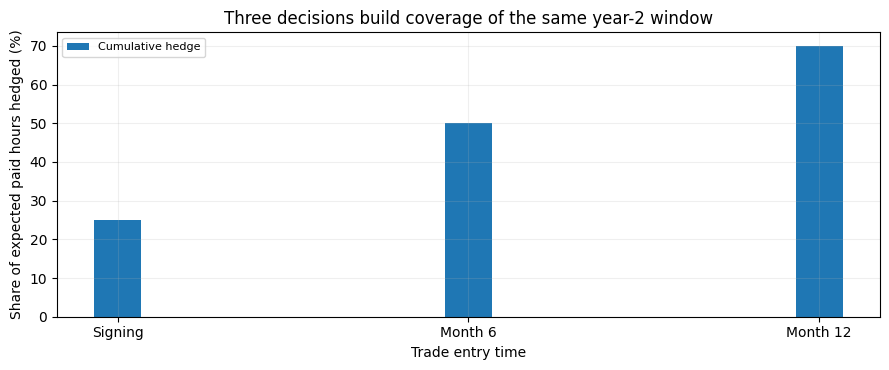

In [18]:
gpu_count, months, hours_per_month, utilization = 64, 12, 730, 0.90
purchase_rate = 4.25
available_year2_hours = gpu_count * months * hours_per_month
expected_year2_hours = available_year2_hours * utilization
entry_times, added_fractions, fixed_rates = (
    [0, 6, 12],
    [0.25, 0.25, 0.20],
    [4.90, 5.10, 4.75],
)
layer_hours = [expected_year2_hours * fraction for fraction in added_fractions]
total_hedged_hours = sum(layer_hours)
weighted_fixed_rate = (
    sum(h * rate for h, rate in zip(layer_hours, fixed_rates)) / total_hedged_hours
)
cumulative_ratios = [sum(added_fractions[: i + 1]) for i in range(len(added_fractions))]
show_finance_table(
    ["Entry time (months)", "Added GPU-hours", "Fixed USD/h", "Cumulative coverage"],
    [
        [str(time), quantity, rate, f"{ratio:.0%}"]
        for time, quantity, rate, ratio in zip(
            entry_times, layer_hours, fixed_rates, cumulative_ratios
        )
    ],
)
print(
    f"Total hedged: {total_hedged_hours:,.1f} GPU-hours; weighted fixed rate: {weighted_fixed_rate:.6f} USD/h"
)
rows = []
for index in [4.00, 6.00]:
    hedge_receipts = sum(
        sum(
            row.amount_usd
            for row in forward_settlements_usd(
                benchmark_usd_per_gpu_hour=[index] * months,
                strike_usd_per_gpu_hour=rate,
                hedge_gpu_hours=[quantity / months] * months,
                settlement_months=list(range(13, 25)),
                side="seller",
            )
        )
        for quantity, rate in zip(layer_hours, fixed_rates)
    )
    sales = expected_year2_hours * index
    purchase_cost = available_year2_hours * purchase_rate
    rows.append(
        [
            index,
            hedge_receipts,
            (sales + hedge_receipts) / expected_year2_hours,
            sales - purchase_cost,
            sales + hedge_receipts - purchase_cost,
        ]
    )
show_finance_table(
    [
        "Final index USD/h",
        "Total swap USD",
        "Blended receipts USD/h",
        "Unhedged margin USD",
        "Layered margin USD",
    ],
    rows,
)

display(
    plot_finance_series(
        {"Cumulative hedge": [ratio * 100 for ratio in cumulative_ratios]},
        title="Three decisions build coverage of the same year-2 window",
        ylabel="Share of expected paid hours hedged (%)",
        xlabel="Trade entry time",
        x_values=[0, 6, 12],
        x_tick_labels=["Signing", "Month 6", "Month 12"],
        bar=True,
    )
)

The weighted fixed rate is about **4.93**, but only on the hedged 70%. The entire year's effective receipt rate is `70% × 4.928571… + 30% × final index`. At index 4.00 this is **4.65**; at 6.00 it is **5.25**. Layering reduces sensitivity to the final price; it does not eliminate it.

The low outcome still loses **USD 36,441.60** after the full capacity purchase cost. As in case 10, the cost per paid hour at 90% fill is 4.722222…, not 4.25. Subtracting just the quoted purchase rate gives `4.928571… − 4.25 = USD 0.678571…`. But Alex also pays for unsold hours. Using the full purchase cost per sold hour leaves only `4.928571… − 4.722222… = USD 0.206349…` on the hedged portion before other costs. Lower receipts on the unhedged portion can still make the whole business lose money.

If all 70% had been hedged at the first 4.90 quote, that covered portion would earn less than this particular sequence's 4.928571… rate. Another sequence of future quotes could be worse. These examples show how the program works, not that it outperforms a one-time hedge.

### 12A. Recheck exposure before adding the next layer

An original 70% hedge ratio depends on the original forecast. Existing swaps do not automatically shrink when fewer hours sell. Keep the already-committed **353,203.2 hours** and test actual paid utilization of 90%, 70% and 50%. Coverage relative to actual billed hours is `existing hedge hours ÷ actual billed hours`.

A higher index creates swap payments. With less matching physical revenue, those payments can become harder to fund even when each forward was sensible when entered. That is why a schedule should include an exposure review, not automatic additions based only on the calendar.

In [19]:
available_hours = 64 * 730 * 12
existing_hedge_hours = available_hours * 0.90 * 0.70
show_finance_table(
    [
        "Actual paid utilization",
        "Actual paid hours",
        "Hedge / actual hours",
        "Hours beyond actual exposure",
    ],
    [
        [
            f"{utilization:.0%}",
            available_hours * utilization,
            f"{existing_hedge_hours / (available_hours * utilization):.0%}",
            max(existing_hedge_hours - available_hours * utilization, 0),
        ]
        for utilization in [0.90, 0.70, 0.50]
    ],
)

| Actual paid utilization | Actual paid hours | Hedge / actual hours | Hours beyond actual exposure |
| --- | --- | --- | --- |
| 90% | 504,576.00 | 70% | 0.00 |
| 70% | 392,448.00 | 90% | 0.00 |
| 50% | 280,320.00 | 126% | 72,883.20 |

At 70% actual paid utilization, the existing hedge covers 90% of billed hours. At 50% paid utilization, it covers **126%**. That means **72,883.2 hedged hours have no corresponding customer payment**. The original 70% hedge has not changed size; the business beneath it has become smaller.

**What Alex would ask to design:** a schedule for reviewing forecasts and deciding whether to add another swap. Each review should identify the hours still exposed to changing prices, the existing hedge quantity, and the cash needed if prices rise and swaps require payments. Fixed-price customer bookings already protect a selling rate; hedging those same hours again could create an extra obligation.

The source ideas also propose these possible review triggers. They are examples of rules to evaluate, not trades carried out in this notebook:

| Proposed trigger | What must be clear before using it |
|---|---|
| Hedge another 15% when the forward rate is USD 1 above the purchase rate | 15% of which hours? What is already hedged? The USD 1 difference still excludes idle costs. |
| Reach a lender's 60% coverage requirement | What receipts does the lender count? A swap quantity may not satisfy its definition of contracted revenue. |
| Review protection when customer bookings reach 50% | Are the bookings fixed-price or floating? Fixed-price sales can reduce the need for another hedge. |
| Review when the 1M/12M spread exceeds USD 0.75 | Does that spread describe this business's actual changing purchase and sales prices? |

The purpose of a rule is to make decisions consistently. It still needs a check that the proposed trade matches the hours and cash risk the business has today.

## Compare the three additions

| Product | What the customer is asking for | What the customer gives up or still faces |
|---|---|---|
| Tenor-trade collar | “Help me below a minimum resale price; let me keep gains up to a cap.” | Net premium, payments above the cap, and losses from unsold or unhedged hours |
| Tenor spread put | “Help me if the gap between my two reference rates gets too small.” | An option premium and any difference between the reference spread and actual business receipts |
| Layered hedging | “Let me fix portions of future sales at several different dates.” | Unhedged price changes, uncertain future quotes, and the risk that fewer hours sell than forecast |

The collar combines a put and a call. Layering repeats smaller forward or swap trades. The spread put calculates its payment from two indices, so both must be suitable for settlement. These describe contract designs; actual prices and availability still require quotes.

## Turn a business concern into a precise request

A **request for quote (RFQ)** asks a potential counterparty what it would charge or offer for stated terms. These examples prepare that request; they do not establish a trade price.

| First identify… | Then write down… |
|---|---|
| What could go wrong | Lower sales price, higher input cost, too few paid hours, or a missed payment |
| What cash outcome matters | A revenue target, margin, maximum bill, or debt-service cushion |
| What is already fixed | Existing customer contracts, purchase commitments and embedded floors/caps |
| The exposed quantity | GPU-hours or MWh, with its month/quarter schedule and reason for that size |
| The payment rule | Who pays whom, how the amount is calculated, and whether it changes the invoice or is a separate payment |
| What must match | Index, actual price, quantities, observation window and cash dates |
| What remains unknown | Option premium, offered fixed rate, collateral, payment reliability and contract conditions |

The protection should follow the actual business exposure. When the concern is low **price**, a price product can help. When the concern is missing **customers**, first identify who commits to pay for volume. When the concern is a **payment date**, align the hedge cash with that date. Several contracts may be needed, but the same exposure should not be counted twice.

For a deeper next step, use [M2: forwards and swaps](M2_forwards_and_swaps.ipynb), [M5: calls and puts](M5_calls_and_puts.ipynb), and the [roadmap](README.md) for lessons on basis, quantity, collateral, power and financing. All source links beside the cases were inspected when this supplement was prepared. Local execution and saved outputs do not establish live Colab verification or product availability.